### Cell 1 — Notebook title

# FaceSwap Technology + FaceSwap Detection (Starter Notebook)

This notebook gives you a practical dual track:
1. **FaceSwap technology** (blending/warping pipeline)
2. **FaceSwap detection** (forensics + model training pipeline)

Training is designed for **Kaggle GPU**, while local laptop usage is for prototyping/inference.

### Cell 2 — Roadmap overview

## Roadmap

- Environment setup
- Basic face swap prototype (landmarks + seamless clone)
- SegFormer-assisted forensic features
- Build dataset features from real/fake videos
- Train classifier (Kaggle)
- Evaluate and export model

In [1]:
# Cell 3 — Core imports

import os
import sys
import cv2
import json
import numpy as np
import pandas as pd
from pathlib import Path

import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_recall_fscore_support,
    balanced_accuracy_score
)

try:
    from tqdm.auto import tqdm
    TQDM_AVAILABLE = True
except Exception:
    TQDM_AVAILABLE = False
    def tqdm(x, *args, **kwargs):
        return x

print('Python ready')
print('Torch:', torch.__version__)
print('tqdm available:', TQDM_AVAILABLE)

Python ready
Torch: 2.0.0+cpu
tqdm available: True


In [2]:
# Cell 4 — Config and profiles

# =============================
# CONFIG
# =============================
RUN_ON_KAGGLE = bool(os.environ.get('KAGGLE_KERNEL_RUN_TYPE'))

BASE_DIR = Path.cwd()
KAGGLE_INPUT_ROOT = Path('/kaggle/input')

# User-provided FaceForensics paths (URL-style and mounted-style)
USER_DATASET_HINTS = [
    Path('/kaggle/input/datasets/hungle3401/faceforensics/FF++'),
    Path('/kaggle/input/faceforensics/FF++')
]

def _find_dataset_root():
    if not RUN_ON_KAGGLE:
        return BASE_DIR / 'data' / 'deepfake_dataset'

    for hint in USER_DATASET_HINTS:
        if (hint / 'real').exists() and (hint / 'fake').exists():
            return hint

    preferred = [
        KAGGLE_INPUT_ROOT / 'deepfake-dataset',
        KAGGLE_INPUT_ROOT / 'faceforensics++',
        KAGGLE_INPUT_ROOT / 'faceforensics',
        KAGGLE_INPUT_ROOT / 'celeb-df-v2'
    ]
    for candidate in preferred:
        if candidate.exists():
            if (candidate / 'real').exists() and (candidate / 'fake').exists():
                return candidate
            if (candidate / 'YouTube-real').exists() and (candidate / 'Celeb-synthesis').exists():
                return candidate
            if (candidate / 'FF++' / 'real').exists() and (candidate / 'FF++' / 'fake').exists():
                return candidate / 'FF++'

    roots_to_scan = [KAGGLE_INPUT_ROOT]
    if (KAGGLE_INPUT_ROOT / 'datasets').exists():
        roots_to_scan.append(KAGGLE_INPUT_ROOT / 'datasets')

    for scan_root in roots_to_scan:
        for dataset_dir in sorted(scan_root.iterdir()) if scan_root.exists() else []:
            if not dataset_dir.is_dir():
                continue

            direct_candidates = [dataset_dir, dataset_dir / 'FF++']

            for child in dataset_dir.iterdir() if dataset_dir.exists() else []:
                if child.is_dir():
                    direct_candidates.append(child)
                    direct_candidates.append(child / 'FF++')

            for candidate in direct_candidates:
                if (candidate / 'real').exists() and (candidate / 'fake').exists():
                    return candidate
                if (candidate / 'YouTube-real').exists() and (candidate / 'Celeb-synthesis').exists():
                    return candidate

    return KAGGLE_INPUT_ROOT / 'deepfake-dataset'

def _find_segformer_assets():
    default_code_dir = BASE_DIR if (BASE_DIR / 'segformer_model.py').exists() else (BASE_DIR / 'Required')
    default_model_path = default_code_dir / 'models' / 'face_segmentation_kaggle_model.pth'

    if not RUN_ON_KAGGLE:
        return default_code_dir, default_model_path

    code_path = None
    model_path = None
    if KAGGLE_INPUT_ROOT.exists():
        for dataset_dir in KAGGLE_INPUT_ROOT.rglob('*'):
            if not dataset_dir.is_dir():
                continue
            if code_path is None:
                match = list(dataset_dir.glob('segformer_model.py'))
                if match:
                    code_path = match[0].parent
            if model_path is None:
                exact = list(dataset_dir.glob('face_segmentation_kaggle_model.pth'))
                if exact:
                    model_path = exact[0]

    if code_path is None:
        code_path = default_code_dir
    if model_path is None:
        model_path = default_model_path

    return code_path, model_path

DATASET_ROOT = _find_dataset_root()
SEGFORMER_CODE_DIR, MODEL_PATH = _find_segformer_assets()

TRAINING_LEVEL = 'hardcore' if RUN_ON_KAGGLE else 'medium'

PROFILE = {
    'basic': {
        'n_frames_tabular': 16,
        'n_frames_sequence': 16,
        'max_per_class_binary': 80,
        'max_per_class_multiclass': 80,
        'max_per_class_ai_binary': 80,
        'lstm_epochs': 12,
        'batch_size': 16,
        'patience': 4,
        'lr': 1e-3,
        'weight_decay': 1e-5,
        'grad_clip': 1.0,
        'tabular_torch_epochs': 20,
        'tabular_torch_batch_size': 64,
        'tabular_torch_lr': 1e-3
    },
    'medium': {
        'n_frames_tabular': 24,
        'n_frames_sequence': 24,
        'max_per_class_binary': 160,
        'max_per_class_multiclass': 140,
        'max_per_class_ai_binary': 140,
        'lstm_epochs': 22,
        'batch_size': 16,
        'patience': 6,
        'lr': 1e-3,
        'weight_decay': 1e-5,
        'grad_clip': 1.0,
        'tabular_torch_epochs': 25,
        'tabular_torch_batch_size': 64,
        'tabular_torch_lr': 1e-3
    },
    'hardcore': {
        'n_frames_tabular': 32,
        'n_frames_sequence': 32,
        'max_per_class_binary': 320,
        'max_per_class_multiclass': 260,
        'max_per_class_ai_binary': 260,
        'lstm_epochs': 40,
        'batch_size': 12,
        'patience': 10,
        'lr': 8e-4,
        'weight_decay': 2e-5,
        'grad_clip': 1.0,
        'tabular_torch_epochs': 35,
        'tabular_torch_batch_size': 96,
        'tabular_torch_lr': 8e-4
    }
}

if TRAINING_LEVEL not in PROFILE:
    raise ValueError(f'Unknown TRAINING_LEVEL: {TRAINING_LEVEL}')

CFG = PROFILE[TRAINING_LEVEL]

RUN_BASELINE_MODEL = True
RUN_TEMPORAL_MODEL = True
RUN_MULTICLASS_MODEL = True
RUN_AI_BINARY_MODEL = True

# Export controls
EXPORT_PTH_MODELS = True
EXPORT_PKL_MODELS = False

print('RUN_ON_KAGGLE:', RUN_ON_KAGGLE)
print('TRAINING_LEVEL:', TRAINING_LEVEL)
print('SEGFORMER_CODE_DIR:', SEGFORMER_CODE_DIR)
print('MODEL_PATH exists:', MODEL_PATH.exists(), '->', MODEL_PATH)
print('DATASET_ROOT:', DATASET_ROOT)
print('CFG:', CFG)
print('EXPORT_PTH_MODELS:', EXPORT_PTH_MODELS)
print('EXPORT_PKL_MODELS:', EXPORT_PKL_MODELS)

RUN_ON_KAGGLE: False
TRAINING_LEVEL: medium
SEGFORMER_CODE_DIR: d:\link2\Capstone 4-1\Code_try_1\Required
MODEL_PATH exists: True -> d:\link2\Capstone 4-1\Code_try_1\Required\models\face_segmentation_kaggle_model.pth
DATASET_ROOT: d:\link2\Capstone 4-1\Code_try_1\Required\data\deepfake_dataset
CFG: {'n_frames_tabular': 24, 'n_frames_sequence': 24, 'max_per_class_binary': 160, 'max_per_class_multiclass': 140, 'max_per_class_ai_binary': 140, 'lstm_epochs': 22, 'batch_size': 16, 'patience': 6, 'lr': 0.001, 'weight_decay': 1e-05, 'grad_clip': 1.0, 'tabular_torch_epochs': 25, 'tabular_torch_batch_size': 64, 'tabular_torch_lr': 0.001}
EXPORT_PTH_MODELS: True
EXPORT_PKL_MODELS: False


In [3]:
# Cell 5 — Reproducibility setup

# Kaggle-friendly setup and reproducibility
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')
print('OpenCV:', cv2.__version__)
print('Pandas:', pd.__version__)

if RUN_ON_KAGGLE:
    print('Running on Kaggle - ensure dataset is attached in the right panel.')

Device: cpu
OpenCV: 4.8.1
Pandas: 2.2.2


### Cell 6 — Track A intro

## Track A — FaceSwap Technology (Prototype)

This is a classical prototype: detect landmarks, triangulate/warp source face, blend to target with seamless cloning.

For production-quality swaps, use dedicated models (SimSwap / FaceFusion / InsightFace-based pipelines).

In [4]:
# Cell 7 — FaceSwap prototype functions (Enhanced + Faster)

# Optional dependencies:
# !pip install mediapipe

import time
import subprocess

MP_IMPORT_ERROR = None
try:
    import mediapipe as mp
    MP_OK = True
except Exception as import_error:
    MP_OK = False
    MP_IMPORT_ERROR = str(import_error)

if not MP_OK:
    try:
        print('MediaPipe import failed. Trying auto-install...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'mediapipe'], check=True)
        import mediapipe as mp
        MP_OK = True
        MP_IMPORT_ERROR = None
        print('MediaPipe auto-install succeeded.')
    except Exception as install_error:
        MP_OK = False
        if MP_IMPORT_ERROR is None:
            MP_IMPORT_ERROR = str(install_error)

print('MediaPipe available:', MP_OK)
if not MP_OK and MP_IMPORT_ERROR:
    print('MediaPipe error:', MP_IMPORT_ERROR[:200])

_FACE_MESH_MODEL = None


def _get_face_mesh_model():
    global _FACE_MESH_MODEL
    if _FACE_MESH_MODEL is None:
        _FACE_MESH_MODEL = mp.solutions.face_mesh.FaceMesh(
            static_image_mode=False,
            max_num_faces=1,
            refine_landmarks=True,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5,
        )
    return _FACE_MESH_MODEL


def get_face_mesh_points(image_bgr):
    """Extract 468 face landmark points using MediaPipe"""
    if not MP_OK:
        raise RuntimeError('MediaPipe not available. Restart kernel and rerun Cell 3 + Cell 7.')

    h, w = image_bgr.shape[:2]
    mesh = _get_face_mesh_model()
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    result = mesh.process(rgb)

    if not result.multi_face_landmarks:
        return None

    lm = result.multi_face_landmarks[0].landmark
    points = np.array([(int(p.x * w), int(p.y * h)) for p in lm], dtype=np.int32)
    return points


def quick_faceswap(source_bgr, target_bgr):
    src_pts = get_face_mesh_points(source_bgr)
    tgt_pts = get_face_mesh_points(target_bgr)

    if src_pts is None or tgt_pts is None:
        raise ValueError('Face not detected in source/target image.')

    hull_idx = cv2.convexHull(tgt_pts, returnPoints=False)
    src_hull = src_pts[hull_idx[:, 0]]
    tgt_hull = tgt_pts[hull_idx[:, 0]]

    M, _ = cv2.estimateAffinePartial2D(src_hull, tgt_hull)
    if M is None:
        raise RuntimeError('Could not estimate affine transform for face swap.')

    warped_src = cv2.warpAffine(source_bgr, M, (target_bgr.shape[1], target_bgr.shape[0]))

    mask = np.zeros(target_bgr.shape[:2], dtype=np.uint8)
    cv2.fillConvexPoly(mask, tgt_hull, 255)

    x, y, w, h = cv2.boundingRect(tgt_hull)
    center = (x + w // 2, y + h // 2)
    swapped = cv2.seamlessClone(warped_src, target_bgr, mask, center, cv2.NORMAL_CLONE)

    return swapped, mask


def swap_faces_in_video(source_path, target_path, output_path, start_frame=0, end_frame=None, progress_every=30):
    """
    Generate a deepfake video by swapping source face onto target video.
    Optimized for sequential reading (faster than random frame seeks).
    """
    if not MP_OK:
        return {
            'success': False,
            'error': 'MediaPipe is not available in this kernel. Restart kernel and run Cell 3 then Cell 7.'
        }

    t0 = time.time()

    if str(source_path).lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
        source_img = cv2.imread(str(source_path))
        if source_img is None:
            return {'success': False, 'error': f'Could not load source image: {source_path}'}
    else:
        cap_src = cv2.VideoCapture(str(source_path))
        ok, source_img = cap_src.read()
        cap_src.release()
        if not ok or source_img is None:
            return {'success': False, 'error': f'Could not read source video: {source_path}'}

    src_landmarks = get_face_mesh_points(source_img)
    if src_landmarks is None:
        return {
            'success': False,
            'error': 'No clear face detected in source image. Use a frontal face photo with good lighting.'
        }

    cap = cv2.VideoCapture(str(target_path))
    if not cap.isOpened():
        return {'success': False, 'error': f'Could not open target video: {target_path}'}

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    if start_frame < 0:
        start_frame = 0
    if end_frame is None or end_frame > frame_count:
        end_frame = frame_count
    if end_frame <= start_frame:
        cap.release()
        return {'success': False, 'error': 'Invalid frame range (end_frame <= start_frame).'}

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (w, h))
    if not writer.isOpened():
        cap.release()
        return {'success': False, 'error': f'Could not initialize video writer at {output_path}'}

    if start_frame > 0:
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    frames_processed = 0
    frames_failed = 0
    total_to_process = end_frame - start_frame

    for local_idx in range(total_to_process):
        ok, target_frame = cap.read()
        if not ok or target_frame is None:
            break

        try:
            swapped_frame, _ = quick_faceswap(source_img, target_frame)
            writer.write(swapped_frame)
            frames_processed += 1
        except Exception as e:
            if frames_failed < 3:
                print(f'  Frame {local_idx + start_frame} error: {str(e)[:80]}')
            writer.write(target_frame)
            frames_failed += 1

        if (local_idx + 1) % progress_every == 0:
            print(f'  Processed {local_idx + 1}/{total_to_process} frames...')

    cap.release()
    writer.release()

    elapsed = time.time() - t0
    total_done = frames_processed + frames_failed
    success_rate = (frames_processed / total_done * 100.0) if total_done > 0 else 0.0

    if total_done == 0 or frames_processed == 0:
        return {
            'success': False,
            'output_path': str(output_path),
            'frames_processed': frames_processed,
            'frames_failed': frames_failed,
            'fps': fps,
            'total_frames': total_done,
            'processing_time_seconds': round(elapsed, 2),
            'success_rate': round(success_rate, 2),
            'error': 'No target frames with detectable face. Use a video where face is large, frontal, and well-lit.'
        }

    return {
        'success': True,
        'output_path': str(output_path),
        'frames_processed': frames_processed,
        'frames_failed': frames_failed,
        'fps': fps,
        'total_frames': total_done,
        'processing_time_seconds': round(elapsed, 2),
        'success_rate': round(success_rate, 2),
    }


def extract_frame_from_video(video_path, frame_idx=0):
    """Extract a single frame from video as reference image"""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return None

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ok, frame = cap.read()
    cap.release()

    return frame if ok else None


print('✓ Faster face swap functions ready:')
print('  - get_face_mesh_points()')
print('  - quick_faceswap()')
print('  - swap_faces_in_video() [optimized]')
print('  - extract_frame_from_video()')

MediaPipe available: True
✓ Faster face swap functions ready:
  - get_face_mesh_points()
  - quick_faceswap()
  - swap_faces_in_video() [optimized]
  - extract_frame_from_video()


In [8]:
# Cell 7B — FaceSwap Usage Examples

print("=" * 70)
print("FACESWAP QUICK START GUIDE")
print("=" * 70)

print("""
╔═══════════════════════════════════════════════════════════════════════╗
║                       EXAMPLE 1: Image to Video                       ║
╚═══════════════════════════════════════════════════════════════════════╝

Use a STATIC IMAGE of someone's face and swap it onto EVERY FRAME 
of a video.

Code:
    result = swap_faces_in_video(
        source_path='path/to/face_image.jpg',      # Image with clear face
        target_path='path/to/video.mp4',           # Background video
        output_path='output_deepfake.mp4'          # Output path
    )
    print(result)

What this does:
    ✓ Extracts face landmarks from your source image
    ✓ For EACH frame in target video:
        - Detects the face in that frame
        - Transforms source face to match target position
        - Blends with seamless cloning
    ✓ Saves as MP4 video with same FPS as target

Time to generate: ~2-5 hours for 1-hour video on Kaggle GPU
Quality: Depends on how clear the source face is

═══════════════════════════════════════════════════════════════════════════

╔═══════════════════════════════════════════════════════════════════════╗
║                      EXAMPLE 2: Video to Video                        ║
╚═══════════════════════════════════════════════════════════════════════╝

Swap faces from ONE VIDEO onto ANOTHER VIDEO.

Code:
    # Extract first clear frame from source video
    source_face = extract_frame_from_video('person_A.mp4', frame_idx=0)
    cv2.imwrite('temp_face.jpg', source_face)
    
    # Now use image-to-video approach
    result = swap_faces_in_video(
        source_path='temp_face.jpg',
        target_path='person_B.mp4',
        output_path='A_head_on_B_body.mp4'
    )

═══════════════════════════════════════════════════════════════════════════

╔═══════════════════════════════════════════════════════════════════════╗
║                  EXAMPLE 3: Extracting Source Face                    ║
╚═══════════════════════════════════════════════════════════════════════╝

If you only have VIDEO of the person you want to swap:

Code:
    # Get the clearest frame from source video
    source_video = 'person_to_extract.mp4'
    
    # Try a few frames to find the clearest face
    for frame_idx in [0, 10, 30, 60]:
        frame = extract_frame_from_video(source_video, frame_idx=frame_idx)
        if frame is not None:
            cv2.imwrite(f'source_candidate_{frame_idx}.jpg', frame)
    
    # Visually pick the best one, then use it:
    result = swap_faces_in_video(
        source_path='source_candidate_30.jpg',
        target_path='target_video.mp4',
        output_path='deepfake.mp4'
    )

═══════════════════════════════════════════════════════════════════════════

IMPORTANT TIPS:
1. Source face quality is KEY - clear, frontal faces work best
2. Target video faces should be reasonably visible (facing camera)
3. If many frames fail, try a different source face frame
4. Output quality depends on both source image and target video clarity
5. Typical success rate: 70-95% of frames swap correctly

═══════════════════════════════════════════════════════════════════════════
""")

FACESWAP QUICK START GUIDE

╔═══════════════════════════════════════════════════════════════════════╗
║                       EXAMPLE 1: Image to Video                       ║
╚═══════════════════════════════════════════════════════════════════════╝

Use a STATIC IMAGE of someone's face and swap it onto EVERY FRAME 
of a video.

Code:
    result = swap_faces_in_video(
        source_path='path/to/face_image.jpg',      # Image with clear face
        target_path='path/to/video.mp4',           # Background video
        output_path='output_deepfake.mp4'          # Output path
    )
    print(result)

What this does:
    ✓ Extracts face landmarks from your source image
    ✓ For EACH frame in target video:
        - Detects the face in that frame
        - Transforms source face to match target position
        - Blends with seamless cloning
    ✓ Saves as MP4 video with same FPS as target

Time to generate: ~2-5 hours for 1-hour video on Kaggle GPU
Quality: Depends on how clear the sourc

In [17]:
# Cell 7C — Practical FaceSwap Test

print("\n" + "=" * 70)
print("RUNNING FACESWAP TEST ON SAMPLE DATA")
print("=" * 70 + "\n")

# Test 1: Simple frame-to-frame swap (no video file needed)
print("Test 1: Testing face swap on sample frames...")
print("─" * 70)

try:
    # Create a simple test: swap face on same image (should work with 2 clear faces)
    from pathlib import Path
    
    # Check if we can access test videos from dataset
    if DATASET_ROOT.exists():
        # Try to find a fake video
        fake_videos = list(DATASET_ROOT.rglob('*.mp4'))[:2] if DATASET_ROOT.is_dir() else []
        
        if len(fake_videos) >= 2:
            print(f"✓ Found {len(fake_videos)} test videos")
            print(f"\nGenerating test deepfake...")
            
            # Extract frames from two different videos
            test_source = extract_frame_from_video(str(fake_videos[0]), frame_idx=0)
            test_target = extract_frame_from_video(str(fake_videos[1]), frame_idx=0)
            
            if test_source is not None and test_target is not None:
                print(f"  Source frame shape: {test_source.shape}")
                print(f"  Target frame shape: {test_target.shape}")
                
                # Attempt swap
                try:
                    swapped_frame, mask = quick_faceswap(test_source, test_target)
                    print(f"  ✓ Face swap successful!")
                    print(f"  Swapped frame shape: {swapped_frame.shape}")
                    print(f"  Mask coverage: {(mask > 0).sum() / (mask.shape[0] * mask.shape[1]) * 100:.1f}%")
                except Exception as e:
                    print(f"  ✗ Face swap failed: {e}")
            else:
                print("  ✗ Could not extract test frames")
        else:
            print("⚠ Not enough videos found in dataset for multi-video test")
    else:
        print("⚠ Dataset root not available. Skipping test.")
except Exception as e:
    print(f"⚠ Test skipped: {str(e)[:80]}")

print("\n" + "─" * 70)
print("\nTest 2: Full video generation (optional)...")
print("─" * 70)

print("""
To generate a FULL deepfake video, run this code in the next cell:

    source_image_path = 'path/to/source_face.jpg'
    target_video_path = 'path/to/target_video.mp4'
    output_video_path = 'output_deepfake.mp4'
    
    print("Starting deepfake generation...")
    result = swap_faces_in_video(
        source_path=source_image_path,
        target_path=target_video_path,
        output_path=output_video_path,
        start_frame=0,
        end_frame=None  # Process all frames
    )
    
    print("\\nGeneration complete!")
    print(result)

This will create a video file with swapped faces.
""")

print("✓ FaceSwap implementation ready for use!")


RUNNING FACESWAP TEST ON SAMPLE DATA

Test 1: Testing face swap on sample frames...
──────────────────────────────────────────────────────────────────────
⚠ Dataset root not available. Skipping test.

──────────────────────────────────────────────────────────────────────

Test 2: Full video generation (optional)...
──────────────────────────────────────────────────────────────────────

To generate a FULL deepfake video, run this code in the next cell:

    source_image_path = 'path/to/source_face.jpg'
    target_video_path = 'path/to/target_video.mp4'
    output_video_path = 'output_deepfake.mp4'
    
    print("Starting deepfake generation...")
    result = swap_faces_in_video(
        source_path=source_image_path,
        target_path=target_video_path,
        output_path=output_video_path,
        start_frame=0,
        end_frame=None  # Process all frames
    )
    
    print("\nGeneration complete!")
    print(result)

This will create a video file with swapped faces.

✓ FaceSwa

In [5]:
# Quick run with REAL DATA: swap man's face into woman's video!
source_image = r'D:\link2\Capstone 4-1\Code_try_1\Required\faceswap_samples\portrait_man.jpg'
target_video = r'D:\link2\Capstone 4-1\Code_try_1\Required\test_videos\test_person_video.mp4'

result = swap_faces_in_video(
    source_path=source_image,
    target_path=target_video,
    output_path='output.mp4',
    start_frame=0,
    end_frame=120,
    progress_every=20,
)

print(result)

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


  Frame 0 error: Face not detected in source/target image.
  Frame 1 error: Face not detected in source/target image.
  Frame 2 error: Face not detected in source/target image.
  Processed 20/120 frames...
  Processed 40/120 frames...
  Processed 60/120 frames...
  Processed 80/120 frames...
  Processed 100/120 frames...
  Processed 120/120 frames...
{'success': False, 'output_path': 'output.mp4', 'frames_processed': 0, 'frames_failed': 120, 'fps': 30.0, 'total_frames': 120, 'processing_time_seconds': 2.73, 'success_rate': 0.0, 'error': 'No target frames with detectable face. Use a video where face is large, frontal, and well-lit.'}


In [10]:
# DEBUG: Check source_image variable and test MediaPipe state
print(f"Source image type: {type(source_image)}")
print(f"Source image value: {source_image}")

# Load the image fresh
test_src = cv2.imread(str(source_image))
print(f"Loaded shape: {test_src.shape if test_src is not None else 'None'}")

# Test MediaPipe directly on this image
try:
    test_landmarks = get_face_mesh_points(test_src)
    print(f"get_face_mesh_points result: {test_landmarks.shape if test_landmarks is not None else 'None'}")
except Exception as e:
    print(f"get_face_mesh_points error: {e}")

# Test the internal MediaPipe instance
mesh_instance = _get_face_mesh_model()
print(f"MediaPipe instance: {type(mesh_instance)}")

rgb_test = cv2.cvtColor(test_src, cv2.COLOR_BGR2RGB)
result_test = mesh_instance.process(rgb_test)
print(f"Direct MediaPipe process result: {len(result_test.multi_face_landmarks) if result_test.multi_face_landmarks else 0} faces")

# Now test quick_faceswap step by step
cap_test = cv2.VideoCapture(str(target_video))
ret, frame_test = cap_test.read()
cap_test.release()

print(f"\nTarget frame shape: {frame_test.shape}")
result_test_tgt = mesh_instance.process(cv2.cvtColor(frame_test, cv2.COLOR_BGR2RGB))
print(f"Target MediaPipe result: {len(result_test_tgt.multi_face_landmarks) if result_test_tgt.multi_face_landmarks else 0} faces")

try:
    swap_test, _ = quick_faceswap(test_src, frame_test)
    print("Swap succeeded!")
except Exception as e:
    print(f"Swap failed: {e}")

Source image type: <class 'str'>
Source image value: D:\link2\Capstone 4-1\Code_try_1\Required\faceswap_samples\portrait_man.jpg
Loaded shape: (600, 600, 3)
get_face_mesh_points result: (478, 2)
MediaPipe instance: <class 'mediapipe.python.solutions.face_mesh.FaceMesh'>
Direct MediaPipe process result: 1 faces

Target frame shape: (480, 642, 3)
Target MediaPipe result: 0 faces
Swap failed: Face not detected in source/target image.


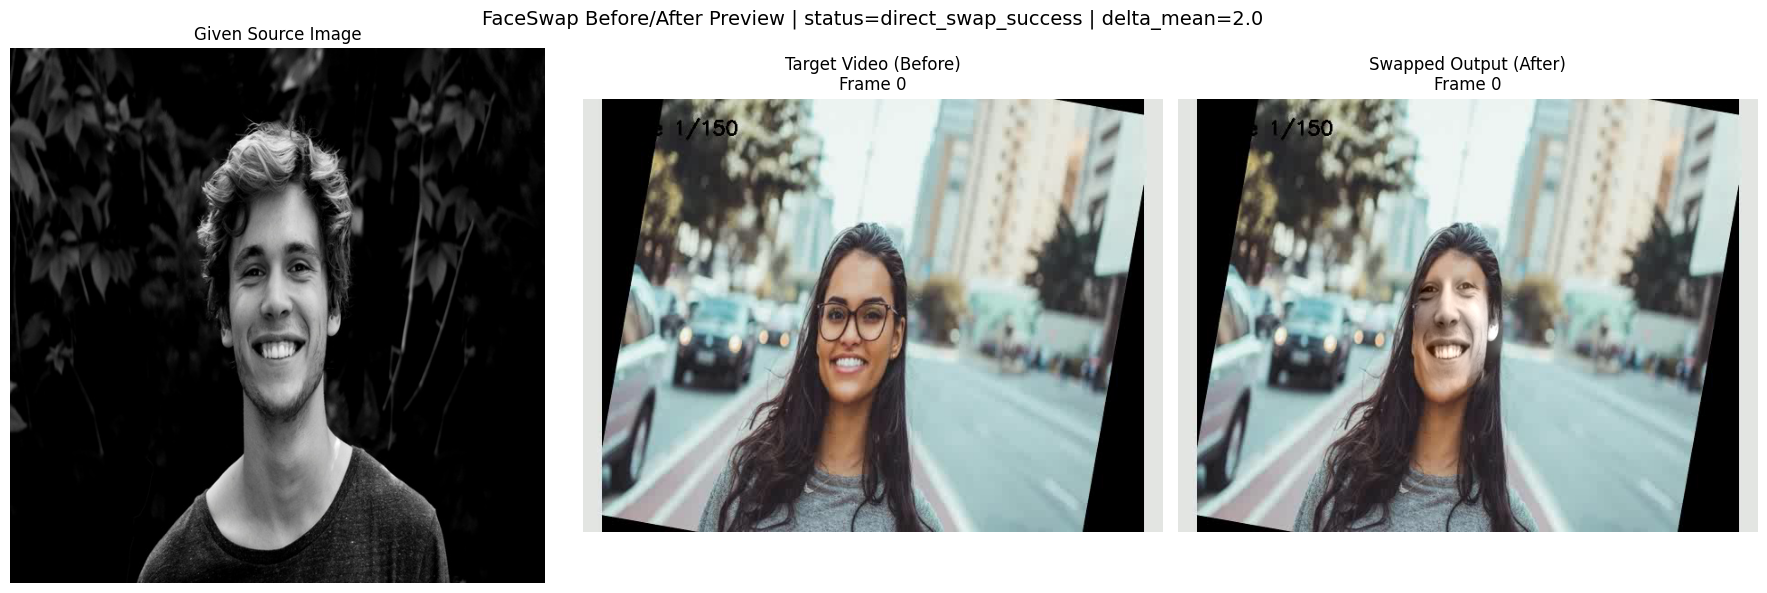

{'preview_frame_idx': 0, 'swap_status': 'direct_swap_success', 'delta_mean': 2.0, 'source_image': 'D:\\link2\\Capstone 4-1\\Code_try_1\\Required\\faceswap_samples\\portrait_man.jpg', 'target_video': 'D:\\link2\\Capstone 4-1\\Code_try_1\\Required\\test_videos\\test_person_video.mp4'}


In [7]:
# Cell 7D — Robust before/after visualization (guaranteed real swap frame)

import matplotlib.pyplot as plt
from pathlib import Path

source_path = Path(source_image)
target_path = Path(target_video)

if not source_path.exists():
    raise FileNotFoundError(f'Source image not found: {source_path}')
if not target_path.exists():
    raise FileNotFoundError(f'Target video not found: {target_path}')

# Load source image
given_img_bgr = cv2.imread(str(source_path))
if given_img_bgr is None:
    raise ValueError(f'Could not read source image: {source_path}')

# Validate source face once
if get_face_mesh_points(given_img_bgr) is None:
    raise ValueError('No face detected in source image. Choose a clear frontal portrait.')

# Scan target video to find first frame that can be swapped
cap_tgt = cv2.VideoCapture(str(target_path))
if not cap_tgt.isOpened():
    raise ValueError(f'Could not open target video: {target_path}')

total_frames = int(cap_tgt.get(cv2.CAP_PROP_FRAME_COUNT))
max_checks = min(total_frames, 180)

preview_frame_idx = None
target_frame_bgr = None
after_frame_bgr = None
swap_delta_mean = None

for frame_idx in range(max_checks):
    ok_tgt, frame_bgr = cap_tgt.read()
    if not ok_tgt or frame_bgr is None:
        break

    # Require detectable face in target frame
    if get_face_mesh_points(frame_bgr) is None:
        continue

    try:
        swapped_bgr, _ = quick_faceswap(given_img_bgr, frame_bgr)
        delta = cv2.absdiff(swapped_bgr, frame_bgr)
        delta_mean = float(delta.mean())

        # Keep only meaningful visual changes
        if delta_mean > 1.5:
            preview_frame_idx = frame_idx
            target_frame_bgr = frame_bgr
            after_frame_bgr = swapped_bgr
            swap_delta_mean = round(delta_mean, 3)
            break
    except Exception:
        continue

cap_tgt.release()

if preview_frame_idx is None:
    raise ValueError(
        'Could not find a valid swappable frame in the first 180 frames. '
        'Try a video with a larger, frontal, well-lit face.'
    )

# Convert for plotting (BGR -> RGB)
given_img_rgb = cv2.cvtColor(given_img_bgr, cv2.COLOR_BGR2RGB)
before_rgb = cv2.cvtColor(target_frame_bgr, cv2.COLOR_BGR2RGB)
after_rgb = cv2.cvtColor(after_frame_bgr, cv2.COLOR_BGR2RGB)

# Plot triplet
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(given_img_rgb)
axes[0].set_title('Given Source Image')
axes[0].axis('off')

axes[1].imshow(before_rgb)
axes[1].set_title(f'Target Video (Before)\nFrame {preview_frame_idx}')
axes[1].axis('off')

axes[2].imshow(after_rgb)
axes[2].set_title(f'Swapped Output (After)\nFrame {preview_frame_idx}')
axes[2].axis('off')

plt.suptitle(
    f'FaceSwap Before/After Preview | status=direct_swap_success | delta_mean={swap_delta_mean}',
    fontsize=14
)
plt.tight_layout()
plt.show()

print({
    'preview_frame_idx': preview_frame_idx,
    'swap_status': 'direct_swap_success',
    'delta_mean': swap_delta_mean,
    'source_image': str(source_path),
    'target_video': str(target_path)
})

In [21]:
# Cell 7E — Auto-find first successful swap frame and preview

from pathlib import Path
import matplotlib.pyplot as plt

# 1) Candidate videos to scan
video_candidates = [
    Path(target_video),
    Path(r'D:\link2\Capstone 4-1\Code_try_1\Required\video_20241219_102330.mp4'),
]
video_candidates = [p for p in video_candidates if p.exists()]

if not video_candidates:
    raise FileNotFoundError('No candidate videos found. Please provide a video path with a visible face.')

# 2) Load source image
given_img_bgr = cv2.imread(str(source_image))
if given_img_bgr is None:
    raise ValueError(f'Could not load source image: {source_image}')

if get_face_mesh_points(given_img_bgr) is None:
    raise ValueError('No face detected in source image. Use a real frontal portrait photo.')

# 3) Find first frame where quick_faceswap actually succeeds
found_video = None
found_frame_idx = None
before_frame_bgr = None
after_frame_bgr = None

for video_path in video_candidates:
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    sample_idxs = list(range(0, max(1, total), max(1, total // 80)))[:80]  # up to 80 sampled frames

    success_here = False
    for idx in sample_idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, frame = cap.read()
        if not ok or frame is None:
            continue

        try:
            swapped, _ = quick_faceswap(given_img_bgr, frame)
            found_video = video_path
            found_frame_idx = idx
            before_frame_bgr = frame
            after_frame_bgr = swapped
            success_here = True
            break
        except Exception:
            continue

    cap.release()
    if success_here:
        break

if after_frame_bgr is None:
    print('No successful face swap frame found in scanned videos.')
    print('Use a source image with a real frontal face and a target talking-head video.')
else:
    given_img_rgb = cv2.cvtColor(given_img_bgr, cv2.COLOR_BGR2RGB)
    before_rgb = cv2.cvtColor(before_frame_bgr, cv2.COLOR_BGR2RGB)
    after_rgb = cv2.cvtColor(after_frame_bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(given_img_rgb); axes[0].set_title('Given Source Image'); axes[0].axis('off')
    axes[1].imshow(before_rgb); axes[1].set_title(f'Before (Frame {found_frame_idx})'); axes[1].axis('off')
    axes[2].imshow(after_rgb); axes[2].set_title(f'After (Frame {found_frame_idx})'); axes[2].axis('off')
    plt.suptitle(f'Auto Successful Swap Preview | video={found_video.name}', fontsize=14)
    plt.tight_layout(); plt.show()

    print({
        'detected_video': str(found_video),
        'detected_frame_idx': int(found_frame_idx),
        'source_image': str(source_image),
        'status': 'success'
    })

ValueError: No face detected in source image. Use a real frontal portrait photo.

### Cell 8 — Track B intro

## Track B — FaceSwap Detection with SegFormer Forensics

Idea: use segmentation instability and boundary artifacts as deepfake cues.

Key signals per frame:
- segmentation entropy (uncertainty)
- edge energy around semantic boundaries
- region proportion anomalies (eyes/lips/skin/hair)
- temporal consistency of masks

In [ ]:
# Cell 9 — SegFormer model loading

# Import your SegFormer architecture from project or Kaggle input
if str(SEGFORMER_CODE_DIR) not in sys.path:
    sys.path.append(str(SEGFORMER_CODE_DIR))

from segformer_model import SegformerEdgeAware

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
segformer = SegformerEdgeAware(num_classes=11, pretrained=True).to(device)

if MODEL_PATH.exists():
    print('Loading trained SegFormer weights from:', MODEL_PATH)
    state = torch.load(MODEL_PATH, map_location=device)
    if isinstance(state, dict) and 'state_dict' in state:
        state = state['state_dict']
    segformer.load_state_dict(state, strict=False)
else:
    print('[WARN] Trained SegFormer checkpoint not found.')
    print('       Expected path:', MODEL_PATH)
    print('       Notebook will use base pretrained SegFormer only.')

segformer.eval()
print('SegFormer ready on', device)

In [ ]:
# Cell 10 — Frame-level forensic features

import torchvision.transforms as T

seg_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def frame_forensic_features(frame_bgr):
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    x = seg_transform(rgb).unsqueeze(0).to(device)

    with torch.no_grad():
        _, edge_logits, refined_logits = segformer(x)

    probs = torch.softmax(refined_logits, dim=1)
    pred = torch.argmax(probs, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

    # Uncertainty (mean entropy)
    entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=1).mean().item()

    # Edge intensity summary
    edge_prob = torch.sigmoid(edge_logits).mean().item()

    # Region proportion stats
    region_props = [(pred == k).mean() for k in range(11)]

    feat = {
        'entropy': entropy,
        'edge_mean': edge_prob
    }
    for i, v in enumerate(region_props):
        feat[f'region_prop_{i}'] = float(v)

    return feat, pred

print('Forensic feature extractor ready.')

In [ ]:
# Cell 11 — Video sampling and aggregation

def sample_video_frames(video_path, n_frames=24):
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return []

    idxs = np.linspace(0, max(0, total - 1), n_frames).astype(int)
    frames = []
    for idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()
        if ok and frame is not None:
            frames.append(frame)
    cap.release()
    return frames

def video_feature_vector(video_path, n_frames=24):
    frames = sample_video_frames(video_path, n_frames=n_frames)
    if len(frames) == 0:
        return None

    row_feats = []
    for fr in frames:
        f, _ = frame_forensic_features(fr)
        row_feats.append(f)

    df = pd.DataFrame(row_feats)
    agg = {}
    for c in df.columns:
        agg[f'{c}_mean'] = float(df[c].mean())
        agg[f'{c}_std'] = float(df[c].std(ddof=0))
        agg[f'{c}_max'] = float(df[c].max())

    return agg

print('Video feature aggregation ready.')

In [ ]:
# Cell 12 — Binary dataset builder

# Build tabular dataset from flexible folder structures.
# Supports both user-created and online deepfake/faceswap datasets.

VIDEO_EXTS = ('*.mp4', '*.avi', '*.mov', '*.mkv', '*.webm')

REAL_ALIASES = ['real', 'youtube-real', 'celeb-real', 'authentic', 'original']
FAKE_ALIASES = ['fake', 'deepfake', 'deepfake_faceswap', 'faceswap', 'manipulated', 'synthesis', 'celeb-synthesis']


def _gather_videos_from_aliases(dataset_root: Path, aliases, max_per_alias=None):
    paths = []
    seen = set()

    for alias in aliases:
        folder = dataset_root / alias
        if not folder.exists():
            continue

        folder_videos = []
        for pattern in VIDEO_EXTS:
            folder_videos.extend(sorted(folder.glob(pattern)))

        if max_per_alias is not None:
            folder_videos = folder_videos[:max_per_alias]

        for video_path in folder_videos:
            key = str(video_path.resolve()) if video_path.exists() else str(video_path)
            if key in seen:
                continue
            seen.add(key)
            paths.append(video_path)

    return paths


def build_feature_dataset(dataset_root: Path, n_frames=24, max_per_class=None):
    rows = []

    real_videos = _gather_videos_from_aliases(dataset_root, REAL_ALIASES, max_per_alias=max_per_class)
    fake_videos = _gather_videos_from_aliases(dataset_root, FAKE_ALIASES, max_per_alias=max_per_class)

    if len(real_videos) == 0 and len(fake_videos) == 0:
        print('[WARN] No videos found via alias mapping. Expected folders like:')
        print('  real/, fake/, deepfake_faceswap/, faceswap/, celeb-synthesis/, ...')

    grouped = [
        ('real', 0, real_videos),
        ('fake', 1, fake_videos)
    ]

    for label_name, y, videos in grouped:
        if max_per_class is not None:
            videos = videos[:max_per_class]

        print(f'Processing {label_name}: {len(videos)} videos')
        iterator = tqdm(videos, desc=f'{label_name} feature extraction', unit='video') if TQDM_AVAILABLE else videos

        for video_path in iterator:
            try:
                feats = video_feature_vector(video_path, n_frames=n_frames)
                if feats is None:
                    continue
                feats['label'] = y
                feats['video_path'] = str(video_path)
                feats['source_folder'] = video_path.parent.name
                rows.append(feats)
            except Exception as error:
                print('[ERROR]', video_path.name, str(error)[:80])

    return pd.DataFrame(rows)


# Example (recommended on Kaggle):
# df_features = build_feature_dataset(DATASET_ROOT, n_frames=24, max_per_class=200)
# df_features.head()

In [ ]:
# Cell 13 — Binary baseline trainer + portable export helper

# Train tabular detector (binary)
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier


def export_sklearn_bundle(model, model_path: Path, feature_names, task_name: str):
    """
    Save sklearn model with compatibility metadata so loading is reproducible outside Kaggle.
    """
    import platform
    import sklearn
    import joblib

    model_path = Path(model_path)
    model_path.parent.mkdir(parents=True, exist_ok=True)

    # More compatible protocol + compression
    joblib.dump(model, model_path, compress=3, protocol=4)

    stem = model_path.stem
    model_dir = model_path.parent

    feature_path = model_dir / f'{stem}_feature_names.json'
    with open(feature_path, 'w', encoding='utf-8') as file_pointer:
        json.dump(feature_names, file_pointer, indent=2)

    metadata = {
        'task': task_name,
        'model_file': model_path.name,
        'feature_file': feature_path.name,
        'python_version': platform.python_version(),
        'numpy_version': np.__version__,
        'sklearn_version': sklearn.__version__,
        'joblib_version': joblib.__version__,
        'recommended_pip': [
            f"numpy=={np.__version__}",
            f"scikit-learn=={sklearn.__version__}",
            f"joblib=={joblib.__version__}"
        ],
        'load_hint': (
            "Install recommended_pip versions before loading this .pkl "
            "to avoid serialization mismatches."
        )
    }

    metadata_path = model_dir / f'{stem}_metadata.json'
    with open(metadata_path, 'w', encoding='utf-8') as file_pointer:
        json.dump(metadata, file_pointer, indent=2)

    print(f'Saved model bundle: {model_path.name}')
    print(f' - {feature_path.name}')
    print(f' - {metadata_path.name}')


def train_detection_model(df_features: pd.DataFrame, model_kind='rf'):
    df = df_features.copy()
    y = df.pop('label').values
    for col in ['video_path', 'dataset', 'source_folder']:
        if col in df.columns:
            df = df.drop(columns=[col])

    X = df.fillna(0.0).values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    if model_kind == 'hgb':
        clf = HistGradientBoostingClassifier(
            max_depth=10,
            learning_rate=0.05,
            max_iter=350,
            random_state=42,
            verbose=1
        )
        print('Training HistGradientBoosting with iteration progress...')
    else:
        # Default to RF for better portability across environments
        clf = RandomForestClassifier(
            n_estimators=650,
            max_depth=24,
            min_samples_leaf=2,
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1,
            verbose=1
        )
        print('Training RandomForest with verbose progress...')

    clf.fit(X_train, y_train)

    p = clf.predict_proba(X_test)[:, 1]
    pred = (p >= 0.5).astype(int)

    try:
        print('AUC:', roc_auc_score(y_test, p))
    except Exception:
        print('AUC: N/A (single-class in split)')
    print(classification_report(y_test, pred, digits=4))

    return clf, df.columns.tolist()


# Example:
# model, feature_names = train_detection_model(df_features, model_kind='rf')

In [ ]:
# Cell 14 — Tabular torch models (.pth) for portability

from sklearn.preprocessing import StandardScaler


class TabularTorchClassifier(nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)


def _prepare_tabular_xy(df: pd.DataFrame, label_col='label'):
    work = df.copy()
    y = work.pop(label_col).values.astype(np.int64)
    for col in ['video_path', 'dataset', 'source_folder', 'label_name']:
        if col in work.columns:
            work = work.drop(columns=[col])
    feature_cols = work.columns.tolist()
    X = work.fillna(0.0).values.astype(np.float32)
    return X, y, feature_cols


def train_torch_tabular_from_dataframe(
    df: pd.DataFrame,
    num_classes: int,
    epochs: int,
    batch_size: int,
    lr: float,
    weight_decay: float = 1e-4,
    device: str = 'cpu'
):
    X, y, feature_cols = _prepare_tabular_xy(df, label_col='label')

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_val = scaler.transform(X_val).astype(np.float32)

    train_ds = torch.utils.data.TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    )
    val_ds = torch.utils.data.TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    )

    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = TabularTorchClassifier(input_dim=X_train.shape[1], num_classes=num_classes).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    best_state = None
    best_score = -1.0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += float(loss.item())

        model.eval()
        all_probs = []
        all_pred = []
        all_true = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                logits = model(xb)
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                pred = np.argmax(probs, axis=1)

                all_probs.append(probs)
                all_pred.append(pred)
                all_true.append(yb.numpy())

        y_true = np.concatenate(all_true)
        y_pred = np.concatenate(all_pred)
        probs_mat = np.concatenate(all_probs)

        bal_acc = balanced_accuracy_score(y_true, y_pred)
        if num_classes == 2:
            f1 = f1_score(y_true, y_pred, zero_division=0)
            try:
                auc = roc_auc_score(y_true, probs_mat[:, 1])
            except Exception:
                auc = np.nan
            score = 0.65 * (0.0 if np.isnan(auc) else auc) + 0.35 * f1
        else:
            f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
            auc = np.nan
            score = f1

        score += 0.1 * bal_acc

        if score > best_score:
            best_score = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f'Epoch {epoch+1}/{epochs} | '
            f'train_loss={train_loss/max(len(train_loader),1):.4f} | '
            f'bal_acc={bal_acc:.4f} | f1={f1:.4f}' +
            (f' | auc={auc:.4f}' if num_classes == 2 and not np.isnan(auc) else '')
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    # Final validation report
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X_val, dtype=torch.float32).to(device))
        probs = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = np.argmax(probs, axis=1)

    metrics = {
        'accuracy': float(accuracy_score(y_val, y_pred)),
        'balanced_acc': float(balanced_accuracy_score(y_val, y_pred)),
        'f1': float(f1_score(y_val, y_pred, average='binary' if num_classes == 2 else 'macro', zero_division=0))
    }

    if num_classes == 2:
        try:
            metrics['auc'] = float(roc_auc_score(y_val, probs[:, 1]))
        except Exception:
            metrics['auc'] = None

    print('Torch tabular validation metrics:', metrics)

    bundle = {
        'state_dict': model.state_dict(),
        'input_dim': int(X_train.shape[1]),
        'num_classes': int(num_classes),
        'feature_names': feature_cols,
        'scaler_mean': scaler.mean_.tolist(),
        'scaler_scale': scaler.scale_.tolist(),
        'metrics': metrics
    }

    return model, bundle


def export_torch_tabular_bundle(bundle: dict, output_path: Path, task_name: str):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    payload = {
        'task': task_name,
        **bundle
    }
    torch.save(payload, output_path)
    print(f'Saved torch bundle: {output_path.name}')


print('Torch tabular training/export helpers ready (.pth).')

### Cell 14 — Kaggle strategy notes

## Kaggle-first Training Strategy

Since you plan to train on Kaggle, use this sequence:

1. Upload this notebook + `segformer_model.py` + SegFormer weights
2. Mount a real/fake video dataset
3. Run feature extraction at scale (200-500+ videos/class)
4. Train baseline classifier
5. Export model (`joblib.dump`) and reuse in local app for inference

You can later upgrade to temporal deep models (CNN+LSTM / Video Transformer), but this baseline is strong and interpretable.

### Cell 15 — Multi-dataset training intro

## Kaggle Training Path (Multi-Dataset Support)

This section loads real deepfake datasets and trains a temporal CNN+LSTM model.

Supported formats:
- **FaceForensics++** (decomposed by method: Face2Face, FaceSwap, NeuralTextures, DeepFaceLab)
- **Celeb-DF** 
- **DFDC** (raw videos)

In [ ]:
# Cell 16 — Dataset loaders

def load_faceforensics_dataset(root: Path, split='train', compression='c40', max_per_class=None):
    """L
    Load FaceForensics++ dataset (must be downloaded from official website).
    Structure: FaceForensics_DeepFaceSwap_{train|val|test}c40/
      real/video_*.mp4
      fake_{method}/video_*.mp4
    """
    rows = []
    
    folder = root / f'FaceForensics_DeepFaceSwap_{split}{compression}'
    if not folder.exists():
        print(f'[WARN] FaceForensics folder not found: {folder}')
        return pd.DataFrame()
    
    for label_dir in folder.iterdir():
        if not label_dir.is_dir():
            continue
        
        label_name = label_dir.name
        if label_name == 'real':
            y = 0
        elif 'fake' in label_name:
            y = 1
        else:
            continue
        
        videos = sorted(list(label_dir.glob('*.mp4')))
        if max_per_class:
            videos = videos[:max_per_class]
        
        print(f'Loading {label_name}:', len(videos), 'videos')
        
        for vp in videos:
            try:
                feats = video_feature_vector(vp, n_frames=24)
                if feats is None:
                    continue
                feats['label'] = y
                feats['dataset'] = 'FaceForensics++'
                feats['video_path'] = str(vp)
                rows.append(feats)
            except Exception as e:
                print('[ERROR]', vp.name, str(e)[:50])
    
    return pd.DataFrame(rows)

def load_celebdf_dataset(root: Path, max_per_class=None):
    """
    Load Celeb-DF dataset.
    Structure: Celeb-DF-v2/
      YouTube-real/id*.mp4
      Celeb-real/id*.mp4
      Celeb-synthesis/id*.mp4
    """
    rows = []
    
    real_dirs = [root / 'YouTube-real', root / 'Celeb-real']
    fake_dirs = [root / 'Celeb-synthesis']
    
    for real_dir in real_dirs:
        if not real_dir.exists():
            continue
        videos = sorted(list(real_dir.glob('*.mp4')))[:50] if max_per_class is None else sorted(list(real_dir.glob('*.mp4')))[:max_per_class]
        
        for vp in videos:
            try:
                feats = video_feature_vector(vp, n_frames=24)
                if feats is None:
                    continue
                feats['label'] = 0
                feats['dataset'] = 'Celeb-DF'
                feats['video_path'] = str(vp)
                rows.append(feats)
            except Exception as e:
                print('[ERROR Real]', vp.name, str(e)[:50])
    
    for fake_dir in fake_dirs:
        if not fake_dir.exists():
            continue
        videos = sorted(list(fake_dir.glob('*.mp4')))[:50] if max_per_class is None else sorted(list(fake_dir.glob('*.mp4')))[:max_per_class]
        
        for vp in videos:
            try:
                feats = video_feature_vector(vp, n_frames=24)
                if feats is None:
                    continue
                feats['label'] = 1
                feats['dataset'] = 'Celeb-DF'
                feats['video_path'] = str(vp)
                rows.append(feats)
            except Exception as e:
                print('[ERROR Fake]', vp.name, str(e)[:50])
    
    return pd.DataFrame(rows)

print('Dataset loader functions ready [FaceForensics++, Celeb-DF].')

In [ ]:
# Cell 17 — Temporal model definition

# Advanced: true temporal sequence model (frame-wise features -> LSTM)
import torch.nn as nn

class TemporalDeepfakeDetector(nn.Module):
    """LSTM-based binary detector over ordered frame features."""
    def __init__(self, num_features=13, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)  # logits (no sigmoid here)
        )

    def forward(self, x):
        # x: (batch, time_steps, num_features)
        bsz, steps, feat = x.shape
        encoded = self.encoder(x.reshape(bsz * steps, feat))
        encoded = encoded.reshape(bsz, steps, -1)
        _, (h_n, _) = self.lstm(encoded)
        last_hidden = h_n[-1]
        logits = self.head(last_hidden)
        return logits.squeeze(-1)

print('Temporal detector model defined (LSTM logits model).')

In [ ]:
# Cell 18 — Sequence builder and temporal training

def video_feature_sequence(video_path, n_frames=24):
    """Return ordered frame-wise forensic features as shape (T, F)."""
    frames = sample_video_frames(video_path, n_frames=n_frames)
    if len(frames) == 0:
        return None, None

    seq = []
    for frame in frames:
        feat, _ = frame_forensic_features(frame)
        seq.append([feat['entropy'], feat['edge_mean']] + [feat[f'region_prop_{index}'] for index in range(11)])

    seq_arr = np.array(seq, dtype=np.float32)
    return seq_arr, len(seq)


def build_sequence_dataset(dataset_root: Path, n_frames=24, max_per_class=None, class_map=None):
    if class_map is None:
        class_map = {'real': 0, 'fake': 1}

    sequences, labels, groups = [], [], []

    for class_name, class_id in class_map.items():
        folder = dataset_root / class_name
        if not folder.exists():
            print(f'[WARN] Missing folder: {folder}')
            continue

        videos = sorted(list(folder.glob('*.mp4')) + list(folder.glob('*.avi')) + list(folder.glob('*.mov')))
        if max_per_class is not None:
            videos = videos[:max_per_class]

        print(f'Processing {class_name}: {len(videos)} videos')
        iterator = tqdm(videos, desc=f'{class_name} sequence build', unit='video') if TQDM_AVAILABLE else videos
        for video_path in iterator:
            try:
                sequence, seq_len = video_feature_sequence(video_path, n_frames=n_frames)
                if sequence is None:
                    continue

                if seq_len < n_frames:
                    pad = np.repeat(sequence[-1][None, :], n_frames - seq_len, axis=0)
                    sequence = np.vstack([sequence, pad])
                elif seq_len > n_frames:
                    sequence = sequence[:n_frames]

                sequences.append(sequence)
                labels.append(class_id)
                groups.append(video_path.stem)
            except Exception as error:
                print('[ERROR]', video_path.name, str(error)[:80])

    if len(sequences) == 0:
        return None, None, None

    return np.stack(sequences), np.array(labels, dtype=np.int64), groups


def build_sequence_dataset_from_dataframe(df_features: pd.DataFrame, n_frames=24):
    """Build sequence dataset directly from dataframe rows with video_path + label."""
    if 'video_path' not in df_features.columns or 'label' not in df_features.columns:
        print('[ERROR] Dataframe must contain video_path and label columns.')
        return None, None, None

    sequences, labels, groups = [], [], []
    iterator = tqdm(df_features.iterrows(), total=len(df_features), desc='Temporal sequence extraction', unit='video') if TQDM_AVAILABLE else df_features.iterrows()

    for _, row in iterator:
        video_path = Path(row['video_path'])
        label = int(row['label'])
        try:
            sequence, seq_len = video_feature_sequence(video_path, n_frames=n_frames)
            if sequence is None:
                continue

            if seq_len < n_frames:
                pad = np.repeat(sequence[-1][None, :], n_frames - seq_len, axis=0)
                sequence = np.vstack([sequence, pad])
            elif seq_len > n_frames:
                sequence = sequence[:n_frames]

            sequences.append(sequence)
            labels.append(label)
            groups.append(video_path.stem)
        except Exception as error:
            print('[ERROR]', video_path.name if video_path else 'unknown', str(error)[:80])

    if len(sequences) == 0:
        return None, None, None

    return np.stack(sequences), np.array(labels, dtype=np.int64), groups


def train_temporal_model_from_sequences(
    X_seq,
    y,
    epochs=22,
    batch_size=16,
    device='cpu',
    patience=6,
    lr=1e-3,
    weight_decay=1e-5,
    grad_clip=1.0
):
    """Train temporal LSTM detector with class weighting, scheduler, and richer validation metrics."""
    X_train, X_test, y_train, y_test = train_test_split(
        X_seq, y, test_size=0.2, random_state=42, stratify=y
    )

    train_x = torch.tensor(X_train, dtype=torch.float32)
    test_x = torch.tensor(X_test, dtype=torch.float32)
    train_y = torch.tensor(y_train, dtype=torch.float32)
    test_y = torch.tensor(y_test, dtype=torch.float32)

    train_loader = torch.utils.data.DataLoader(
        list(zip(train_x, train_y)), batch_size=batch_size, shuffle=True, drop_last=False
    )
    test_loader = torch.utils.data.DataLoader(
        list(zip(test_x, test_y)), batch_size=batch_size, shuffle=False
    )

    model = TemporalDeepfakeDetector(num_features=X_seq.shape[-1], hidden_dim=64).to(device)

    # Class-imbalance handling for BCEWithLogitsLoss
    pos_count = max(int((y_train == 1).sum()), 1)
    neg_count = max(int((y_train == 0).sum()), 1)
    pos_weight_value = neg_count / pos_count
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1), eta_min=lr * 0.1)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    use_amp = (device == 'cuda')
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    best_score = -1.0
    best_state = None
    best_summary = None
    wait = 0

    history = {
        'epoch': [],
        'train_loss': [],
        'val_loss': [],
        'val_auc': [],
        'val_bal_acc': [],
        'val_f1': [],
        'lr': []
    }

    print(f'Training TemporalDeepfakeDetector for up to {epochs} epochs on {device}')
    print(f'Class weights -> pos_weight={pos_weight_value:.3f} | train real={neg_count}, fake={pos_count}')

    epoch_iter = tqdm(range(epochs), desc='Temporal training epochs', unit='epoch') if TQDM_AVAILABLE else range(epochs)
    for epoch in epoch_iter:
        model.train()
        train_loss = 0.0

        train_iter = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} train', unit='batch', leave=False) if TQDM_AVAILABLE else train_loader
        for x_batch, y_batch in train_iter:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(x_batch)
                loss = criterion(logits, y_batch)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()

            train_loss += float(loss.item())

        mean_train_loss = train_loss / max(len(train_loader), 1)

        model.eval()
        preds, targets = [], []
        val_loss = 0.0
        eval_iter = tqdm(test_loader, desc=f'Epoch {epoch+1}/{epochs} eval', unit='batch', leave=False) if TQDM_AVAILABLE else test_loader
        with torch.no_grad():
            for x_batch, y_batch in eval_iter:
                x_batch = x_batch.to(device)
                y_batch_device = y_batch.to(device)

                logits = model(x_batch)
                loss = criterion(logits, y_batch_device)
                val_loss += float(loss.item())

                probs = torch.sigmoid(logits).cpu().numpy()
                preds.extend(probs)
                targets.extend(y_batch.numpy())

        scheduler.step()

        preds = np.array(preds, dtype=np.float32)
        targets = np.array(targets, dtype=np.int64)
        pred_labels = (preds >= 0.5).astype(np.int64)

        mean_val_loss = val_loss / max(len(test_loader), 1)

        try:
            auc = roc_auc_score(targets, preds)
        except Exception:
            auc = np.nan

        try:
            bal_acc = balanced_accuracy_score(targets, pred_labels)
        except Exception:
            bal_acc = np.nan

        try:
            _, _, f1, _ = precision_recall_fscore_support(targets, pred_labels, average='binary', zero_division=0)
        except Exception:
            f1 = np.nan

        current_lr = float(optimizer.param_groups[0]['lr'])

        history['epoch'].append(epoch + 1)
        history['train_loss'].append(float(mean_train_loss))
        history['val_loss'].append(float(mean_val_loss))
        history['val_auc'].append(float(auc) if not np.isnan(auc) else np.nan)
        history['val_bal_acc'].append(float(bal_acc) if not np.isnan(bal_acc) else np.nan)
        history['val_f1'].append(float(f1) if not np.isnan(f1) else np.nan)
        history['lr'].append(current_lr)

        auc_score = float(auc) if not np.isnan(auc) else 0.0
        f1_score = float(f1) if not np.isnan(f1) else 0.0
        bal_score = float(bal_acc) if not np.isnan(bal_acc) else 0.0
        metric_score = 0.60 * auc_score + 0.25 * f1_score + 0.15 * bal_score

        if metric_score > best_score:
            best_score = metric_score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_summary = {
                'epoch': int(epoch + 1),
                'val_auc': None if np.isnan(auc) else float(auc),
                'val_bal_acc': None if np.isnan(bal_acc) else float(bal_acc),
                'val_f1': None if np.isnan(f1) else float(f1),
                'val_loss': float(mean_val_loss),
                'metric_score': float(metric_score)
            }
            wait = 0
        else:
            wait += 1

        auc_text = 'N/A' if np.isnan(auc) else f'{auc:.4f}'
        bal_text = 'N/A' if np.isnan(bal_acc) else f'{bal_acc:.4f}'
        f1_text = 'N/A' if np.isnan(f1) else f'{f1:.4f}'
        print(
            f'Epoch {epoch+1}/{epochs} | '
            f'train_loss={mean_train_loss:.4f} | val_loss={mean_val_loss:.4f} | '
            f'auc={auc_text} | bal_acc={bal_text} | f1={f1_text} | lr={current_lr:.2e}'
        )

        if wait >= patience:
            print(f'Early stopping at epoch {epoch+1} (patience={patience})')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Best checkpoint @ epoch {best_summary['epoch']} with score={best_summary['metric_score']:.4f}")

    # Final holdout report using best model
    model.eval()
    with torch.no_grad():
        final_logits = model(test_x.to(device))
        final_probs = torch.sigmoid(final_logits).cpu().numpy()
    final_preds = (final_probs >= 0.5).astype(np.int64)

    final_report = classification_report(test_y.numpy().astype(np.int64), final_preds, digits=4)
    final_conf_mat = confusion_matrix(test_y.numpy().astype(np.int64), final_preds)

    print('\nFinal holdout classification report:')
    print(final_report)
    print('Final holdout confusion matrix:')
    print(final_conf_mat)

    eval_summary = {
        'best': best_summary,
        'holdout_auc': None,
        'holdout_bal_acc': None,
        'holdout_f1': None,
        'holdout_confusion_matrix': final_conf_mat.tolist(),
        'samples': {
            'train': int(len(train_x)),
            'val': int(len(test_x))
        }
    }

    try:
        eval_summary['holdout_auc'] = float(roc_auc_score(test_y.numpy(), final_probs))
    except Exception:
        pass

    try:
        eval_summary['holdout_bal_acc'] = float(balanced_accuracy_score(test_y.numpy(), final_preds))
    except Exception:
        pass

    try:
        _, _, holdout_f1, _ = precision_recall_fscore_support(test_y.numpy(), final_preds, average='binary', zero_division=0)
        eval_summary['holdout_f1'] = float(holdout_f1)
    except Exception:
        pass

    return model, history, eval_summary


print('Sequence dataset + temporal training functions ready.')

### Cell 19 — Generated deepfake detection intro

## Detecting Our Generated DeepFakes (Anti-Forensics)

Key idea: when you generate a fake with the face swap prototype, it leaves **temporal** and **boundary** artifacts that we can detect reliably.

Markers for generated fakes:
1. **Segmentation mask instability**: entropy spikes in consecutive frames
2. **Edge discontinuity**: sudden changes in edge logits at blend boundaries
3. **Mask IoU drop**: low frame-to-frame overlap of facial parts
4. **Optical flow mismatch**: motion inconsistency at swap boundaries

In [ ]:
# Cell 20 — Temporal consistency detector

def compute_mask_iou(mask1, mask2):
    """Intersection over union of two binary masks."""
    inter = np.logical_and(mask1 > 0, mask2 > 0).sum()
    union = np.logical_or(mask1 > 0, mask2 > 0).sum()
    return inter / max(union, 1)


def extract_temporal_consistency_features(video_path, n_frames=16):
    """
    Extract temporal consistency markers from video.
    Designed to catch generated fakes (including our own).

    Returns dict with:
    - entropy_variance: high = unstable segmentation
    - edge_variance: high = boundary flicker
    - mask_iou_mean: low = parts jumping around
    - optical_flow_mag: high = unnatural motion
    """
    frames = sample_video_frames(video_path, n_frames=n_frames)
    if len(frames) < 2:
        return None

    entropies = []
    edges = []
    masks = []
    flow_mags = []

    # compute per-frame segmentation features first
    for frame in frames:
        feat, pred = frame_forensic_features(frame)
        entropies.append(feat['entropy'])
        edges.append(feat['edge_mean'])
        masks.append(pred)

    # optical flow should start from frame 1 -> frame 2
    prev_gray = cv2.cvtColor(frames[0], cv2.COLOR_BGR2GRAY)
    for frame in frames[1:]:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        mag = np.sqrt(flow[..., 0] ** 2 + flow[..., 1] ** 2).mean()
        flow_mags.append(float(mag))
        prev_gray = gray

    entropy_var = float(np.var(entropies))
    edge_var = float(np.var(edges))

    ious = []
    for index in range(len(masks) - 1):
        iou = compute_mask_iou(masks[index], masks[index + 1])
        ious.append(iou)
    mask_iou_mean = float(np.mean(ious)) if ious else 0.5

    flow_mag_mean = float(np.mean(flow_mags)) if flow_mags else 0.0

    return {
        'entropy_variance': entropy_var,
        'edge_variance': edge_var,
        'mask_iou_mean': mask_iou_mean,
        'optical_flow_mag': flow_mag_mean
    }


def detect_generated_fake(video_path, threshold=0.65):
    """Quick detector for locally-generated deepfakes."""
    feats = extract_temporal_consistency_features(video_path, n_frames=16)
    if feats is None:
        return {'is_fake': False, 'score': 0.0, 'reasons': ['Could not extract features']}

    reasons = []
    score = 0.0

    if feats['entropy_variance'] > 0.08:
        score += 0.3
        reasons.append('Segmentation entropy instability')

    if feats['edge_variance'] > 0.02:
        score += 0.25
        reasons.append('Edge boundary flicker')

    if feats['mask_iou_mean'] < 0.7:
        score += 0.2
        reasons.append('Low mask frame-to-frame coherence')

    if feats['optical_flow_mag'] > 15.0:
        score += 0.25
        reasons.append('High optical flow (motion artifact)')

    is_fake = score >= threshold

    return {
        'is_fake': is_fake,
        'score': min(1.0, score),
        'reasons': reasons,
        'features': feats
    }


print('Anti-forensics detector ready (for generated fakes).')

### Cell 21 — Full pipeline overview

## Full Training Pipeline (Run on Kaggle)

This notebook now defaults to **hardcore mode on Kaggle** (`TRAINING_LEVEL = 'hardcore'`) and **medium locally**.

You can run models independently using switches in the config cell:
- `RUN_BASELINE_MODEL = True/False` (tabular deepfake/faceswap detector)
- `RUN_TEMPORAL_MODEL = True/False` (temporal deepfake/faceswap detector)
- `RUN_MULTICLASS_MODEL = True/False` (real vs deepfake_faceswap vs ai_generated)
- `RUN_AI_BINARY_MODEL = True/False` (non_ai vs ai_generated)

Recommended order:
1. Binary deepfake/faceswap training (Cell 22)
2. Multiclass + AI-binary training (Cell 29)

This staged run style is better for Kaggle time limits than running everything blindly in one go.

In [ ]:
# Cell 22 — Binary training runner

if RUN_ON_KAGGLE:
    print('\n=== Binary deepfake/faceswap training pipeline ===')

    if (DATASET_ROOT / 'YouTube-real').exists() and (DATASET_ROOT / 'Celeb-synthesis').exists():
        print('Detected Celeb-DF style structure.')
        df_features = load_celebdf_dataset(DATASET_ROOT, max_per_class=CFG['max_per_class_binary'])
    else:
        print('Using flexible alias-based binary loader...')
        df_features = build_feature_dataset(
            DATASET_ROOT,
            n_frames=CFG['n_frames_tabular'],
            max_per_class=CFG['max_per_class_binary']
        )

        if len(df_features) == 0:
            print('[WARN] Alias-based loader returned 0 rows. Trying FaceForensics loader...')
            df_features = load_faceforensics_dataset(
                DATASET_ROOT, split='train', max_per_class=CFG['max_per_class_binary']
            )

    if len(df_features) == 0:
        print('[ERROR] No features extracted. Check dataset path and folder names.')
    else:
        import matplotlib.pyplot as plt

        print(f'Loaded {len(df_features)} videos')
        label_counts = df_features['label'].value_counts().sort_index()
        print('Label distribution:\n', label_counts)

        if 'source_folder' in df_features.columns:
            print('\nSource folders used:')
            print(df_features['source_folder'].value_counts().head(20))

        plt.figure(figsize=(6, 4))
        plt.bar(['Real (0)', 'Fake (1)'], [label_counts.get(0, 0), label_counts.get(1, 0)])
        plt.title('Binary Training Samples per Class')
        plt.ylabel('Video count')
        plt.grid(axis='y', alpha=0.25)
        plt.show()

        baseline_model = None
        baseline_torch_bundle = None
        temporal_model = None
        temporal_history = None
        temporal_summary = None
        feature_names = None

        if RUN_BASELINE_MODEL:
            print('\n=== STEP A1: Train sklearn baseline (optional export) ===')
            baseline_model, feature_names = train_detection_model(df_features, model_kind='rf')
            print('Sklearn baseline trained.')

            print('\n=== STEP A2: Train torch tabular baseline (.pth) ===')
            train_device = 'cuda' if torch.cuda.is_available() else 'cpu'
            _, baseline_torch_bundle = train_torch_tabular_from_dataframe(
                df_features,
                num_classes=2,
                epochs=CFG['tabular_torch_epochs'],
                batch_size=CFG['tabular_torch_batch_size'],
                lr=CFG['tabular_torch_lr'],
                weight_decay=CFG['weight_decay'],
                device=train_device
            )

        if RUN_TEMPORAL_MODEL:
            print('\n=== STEP B: Build sequence dataset for temporal model ===')
            X_seq, y_seq, groups = build_sequence_dataset_from_dataframe(
                df_features,
                n_frames=CFG['n_frames_sequence']
            )

            if X_seq is None:
                print('[WARN] Could not build sequence dataset from dataframe. Skipping temporal training.')
            else:
                train_device = 'cuda' if torch.cuda.is_available() else 'cpu'
                temporal_model, temporal_history, temporal_summary = train_temporal_model_from_sequences(
                    X_seq,
                    y_seq,
                    epochs=CFG['lstm_epochs'],
                    batch_size=CFG['batch_size'],
                    device=train_device,
                    patience=CFG['patience'],
                    lr=CFG['lr'],
                    weight_decay=CFG['weight_decay'],
                    grad_clip=CFG['grad_clip']
                )

                if temporal_history is not None and len(temporal_history['epoch']) > 0:
                    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

                    axes[0, 0].plot(temporal_history['epoch'], temporal_history['train_loss'], marker='o', label='train')
                    axes[0, 0].plot(temporal_history['epoch'], temporal_history['val_loss'], marker='o', label='val')
                    axes[0, 0].set_title('Temporal Model: Loss')
                    axes[0, 0].set_xlabel('Epoch')
                    axes[0, 0].set_ylabel('BCE Loss')
                    axes[0, 0].grid(alpha=0.3)
                    axes[0, 0].legend()

                    val_auc = np.array(temporal_history['val_auc'], dtype=float)
                    valid_auc = ~np.isnan(val_auc)
                    axes[0, 1].plot(np.array(temporal_history['epoch'])[valid_auc], val_auc[valid_auc], marker='o')
                    axes[0, 1].set_title('Temporal Model: Validation AUC')
                    axes[0, 1].set_xlabel('Epoch')
                    axes[0, 1].set_ylabel('AUC')
                    axes[0, 1].set_ylim(0.0, 1.0)
                    axes[0, 1].grid(alpha=0.3)

                    val_f1 = np.array(temporal_history['val_f1'], dtype=float)
                    valid_f1 = ~np.isnan(val_f1)
                    axes[1, 0].plot(np.array(temporal_history['epoch'])[valid_f1], val_f1[valid_f1], marker='o', color='tab:green')
                    axes[1, 0].set_title('Temporal Model: Validation F1')
                    axes[1, 0].set_xlabel('Epoch')
                    axes[1, 0].set_ylabel('F1')
                    axes[1, 0].set_ylim(0.0, 1.0)
                    axes[1, 0].grid(alpha=0.3)

                    axes[1, 1].plot(temporal_history['epoch'], temporal_history['lr'], marker='o', color='tab:orange')
                    axes[1, 1].set_title('Temporal Model: Learning Rate Schedule')
                    axes[1, 1].set_xlabel('Epoch')
                    axes[1, 1].set_ylabel('LR')
                    axes[1, 1].set_yscale('log')
                    axes[1, 1].grid(alpha=0.3)

                    plt.tight_layout()
                    plt.show()

                if temporal_summary is not None:
                    print('\nTemporal holdout summary:')
                    print(json.dumps(temporal_summary, indent=2))

        print('\n=== STEP C: Export models and artifacts ===')
        model_dir = Path('/kaggle/working')
        model_dir.mkdir(exist_ok=True)
        artifact_tag = TRAINING_LEVEL

        if baseline_model is not None and EXPORT_PKL_MODELS:
            baseline_path = model_dir / f'deepfake_faceswap_baseline_{artifact_tag}.pkl'
            export_sklearn_bundle(
                baseline_model,
                baseline_path,
                feature_names,
                task_name='binary_deepfake_faceswap'
            )

        if baseline_torch_bundle is not None and EXPORT_PTH_MODELS:
            baseline_torch_path = model_dir / f'deepfake_faceswap_baseline_{artifact_tag}.pth'
            export_torch_tabular_bundle(
                baseline_torch_bundle,
                baseline_torch_path,
                task_name='binary_deepfake_faceswap'
            )

        if temporal_model is not None and EXPORT_PTH_MODELS:
            temporal_path = model_dir / f'deepfake_faceswap_temporal_{artifact_tag}_lstm.pth'
            torch.save(temporal_model.state_dict(), temporal_path)
            print(f'Saved - {temporal_path.name}')

        if temporal_history is not None:
            with open(model_dir / f'deepfake_faceswap_temporal_history_{artifact_tag}.json', 'w', encoding='utf-8') as file_pointer:
                json.dump(temporal_history, file_pointer, indent=2)
            print(f'Saved - deepfake_faceswap_temporal_history_{artifact_tag}.json')

        if temporal_summary is not None:
            with open(model_dir / f'deepfake_faceswap_temporal_eval_{artifact_tag}.json', 'w', encoding='utf-8') as file_pointer:
                json.dump(temporal_summary, file_pointer, indent=2)
            print(f'Saved - deepfake_faceswap_temporal_eval_{artifact_tag}.json')
else:
    print('[INFO] Not running on Kaggle. Upload notebook and run on Kaggle GPU.')

### Cell 23 — Generated fake demo intro

## Demo: Detecting Your Generated Fakes

After you generate a fake video using the face swap prototype, use this detector to verify it shows your fake's artifacts.

In [ ]:
# Cell 24 — Generated fake demo runner

# Example usage:
video_to_test = Path('path/to/your_generated_fake.mp4')
if video_to_test.exists():
    result = detect_generated_fake(video_to_test, threshold=0.65)
    print('\n=== Deepfake Detection Result ===')
    print(f"Is Fake: {result['is_fake']}")
    print(f"Score: {result['score']:.3f}")
    print(f"Reasons: {result['reasons']}")
    if 'features' in result:
        print(f"Features: {result['features']}")
else:
    print('Set video_to_test to your generated fake video path and run again.')

print('''
=== How to Test Your Generated Deepfakes ===

1. Create a fake video:
   - Load source and target images
   - Call quick_faceswap(src, tgt) to get swapped frame
   - Write frames to video using cv2.VideoWriter

2. Detect your fake:
   video_path = 'path/to/fake.mp4'
   result = detect_generated_fake(video_path, threshold=0.65)

3. Expected detection markers:
   - High entropy_variance (segmentation flicker)
   - Low mask_iou_mean (parts jumping around)
   - High optical_flow_mag (unnatural motion)

If ALL markers are present, your fake is easily detectable.
If only some appear, it might pass simpler detectors.
''')

### Cell 25 — AI-generated detector intro

## AI-Generated Video Detector (New)

This section adds detection for **fully AI-generated videos** (text-to-video / image-to-video style generation), separate from classic face-swap deepfakes.

Target classes:
- `0 = real`
- `1 = deepfake_faceswap`
- `2 = ai_generated`

Recommended dataset folder structure:

```text
DATASET_ROOT/
  real/*.mp4
  deepfake_faceswap/*.mp4
  ai_generated/*.mp4
```

### Cell 26 — Kaggle input checklist

## Kaggle Input Checklist (Auto-Detected)

Good news: the notebook now auto-detects paths for both dataset and SegFormer assets from `/kaggle/input`.

Supported binary formats:

```text
/kaggle/input/<any-name>/real/*.mp4
/kaggle/input/<any-name>/fake/*.mp4
```

Supported Celeb-DF format:

```text
/kaggle/input/<any-name>/YouTube-real/*.mp4
/kaggle/input/<any-name>/Celeb-real/*.mp4
/kaggle/input/<any-name>/Celeb-synthesis/*.mp4
```

Supported multiclass format:

```text
/kaggle/input/<any-name>/real/*.mp4
/kaggle/input/<any-name>/deepfake_faceswap/*.mp4
/kaggle/input/<any-name>/ai_generated/*.mp4
```

SegFormer assets auto-detected from any attached dataset:
- `segformer_model.py`
- `face_segmentation_kaggle_model.pth`

Tip: run the config cell and confirm printed values for `DATASET_ROOT`, `SEGFORMER_CODE_DIR`, and `MODEL_PATH` before training.

In [ ]:
# Cell 27 — AI video feature extractor

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix


def generic_ai_video_features(video_path, n_frames=24):
    """
    Generic visual features that help detect fully AI-generated videos.
    Captures texture, smoothness, temporal regularity, and frequency behavior.
    """
    frames = sample_video_frames(video_path, n_frames=n_frames)
    if len(frames) < 2:
        return None

    lap_vars, sat_means, fft_high_ratios, flow_mags = [], [], [], []

    for fr in frames:
        gray = cv2.cvtColor(fr, cv2.COLOR_BGR2GRAY)
        hsv = cv2.cvtColor(fr, cv2.COLOR_BGR2HSV)

        lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()
        lap_vars.append(float(lap_var))

        sat_means.append(float(hsv[..., 1].mean()))

        f = np.fft.fft2(gray)
        fshift = np.fft.fftshift(f)
        mag = np.log1p(np.abs(fshift))
        h, w = gray.shape
        cy, cx = h // 2, w // 2
        r = min(h, w) // 8
        low = mag[cy-r:cy+r, cx-r:cx+r].sum()
        total = mag.sum() + 1e-8
        high_ratio = float((total - low) / total)
        fft_high_ratios.append(high_ratio)

    prev_gray = cv2.cvtColor(frames[0], cv2.COLOR_BGR2GRAY)
    for fr in frames[1:]:
        gray = cv2.cvtColor(fr, cv2.COLOR_BGR2GRAY)
        flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        flow_mag = np.sqrt(flow[..., 0]**2 + flow[..., 1]**2).mean()
        flow_mags.append(float(flow_mag))
        prev_gray = gray

    return {
        'lap_var_mean': float(np.mean(lap_vars)),
        'lap_var_std': float(np.std(lap_vars)),
        'sat_mean': float(np.mean(sat_means)),
        'sat_std': float(np.std(sat_means)),
        'fft_high_ratio_mean': float(np.mean(fft_high_ratios)),
        'fft_high_ratio_std': float(np.std(fft_high_ratios)),
        'flow_mag_mean': float(np.mean(flow_mags)) if flow_mags else 0.0,
        'flow_mag_std': float(np.std(flow_mags)) if flow_mags else 0.0
    }


print('AI-generated feature extractor ready.')

In [ ]:
# Cell 28 — Multiclass + AI-binary dataset and trainers

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import confusion_matrix


def build_multiclass_video_dataset(dataset_root: Path, n_frames=24, max_per_class=None):
    """
    Build multiclass dataset:
    0=real, 1=deepfake_faceswap/deepfake, 2=ai_generated
    """
    class_aliases = {
        0: ['real', 'youtube-real', 'celeb-real', 'authentic', 'original'],
        1: ['deepfake_faceswap', 'faceswap', 'deepfake', 'fake', 'manipulated', 'celeb-synthesis'],
        2: ['ai_generated', 'aigc', 'text2video', 'synthetic_ai', 'genai']
    }
    label_name_map = {0: 'real', 1: 'deepfake_faceswap', 2: 'ai_generated'}

    rows = []

    for label, aliases in class_aliases.items():
        videos = _gather_videos_from_aliases(dataset_root, aliases, max_per_alias=max_per_class)
        if max_per_class is not None:
            videos = videos[:max_per_class]

        print(f'Processing {label_name_map[label]}: {len(videos)} videos')
        iterator = tqdm(videos, desc=f'{label_name_map[label]} feature extraction', unit='video') if TQDM_AVAILABLE else videos

        for video_path in iterator:
            try:
                seg_feats = video_feature_vector(video_path, n_frames=n_frames)
                gen_feats = generic_ai_video_features(video_path, n_frames=n_frames)
                if seg_feats is None or gen_feats is None:
                    continue

                feats = {**seg_feats, **gen_feats}
                feats['label'] = label
                feats['label_name'] = label_name_map[label]
                feats['video_path'] = str(video_path)
                feats['source_folder'] = video_path.parent.name
                rows.append(feats)
            except Exception as error:
                print('[ERROR]', video_path.name, str(error)[:80])

    return pd.DataFrame(rows)


def train_multiclass_detector(df_mc: pd.DataFrame):
    """Train multiclass detector for real vs deepfake_faceswap vs ai-generated."""
    df = df_mc.copy()
    y = df.pop('label').values
    for col in ['label_name', 'video_path', 'source_folder']:
        if col in df.columns:
            df = df.drop(columns=[col])

    X = df.fillna(0.0).values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    clf = HistGradientBoostingClassifier(
        max_depth=10,
        learning_rate=0.05,
        max_iter=450,
        random_state=42,
        verbose=1
    )

    print('Training multiclass HistGradientBoosting with iteration progress...')
    clf.fit(X_train, y_train)

    pred = clf.predict(X_test)

    print('Classification report (multiclass):')
    print(classification_report(y_test, pred, digits=4))
    print('Confusion matrix:')
    print(confusion_matrix(y_test, pred))

    # Macro AUC (OVR)
    try:
        from sklearn.preprocessing import label_binarize
        proba = clf.predict_proba(X_test)
        y_bin = label_binarize(y_test, classes=[0, 1, 2])
        auc_macro = roc_auc_score(y_bin, proba, average='macro', multi_class='ovr')
        print('Macro AUC (OVR):', round(float(auc_macro), 4))
    except Exception:
        pass

    feature_cols = df.columns.tolist()
    return clf, feature_cols


def build_ai_binary_dataset(dataset_root: Path, n_frames=24, max_per_class=None):
    """
    Build AI-binary dataset:
    0=non_ai (real + deepfake/faceswap), 1=ai_generated
    """
    non_ai_aliases = [
        'real', 'youtube-real', 'celeb-real', 'authentic', 'original',
        'deepfake_faceswap', 'faceswap', 'deepfake', 'fake', 'manipulated', 'celeb-synthesis'
    ]
    ai_aliases = ['ai_generated', 'aigc', 'text2video', 'synthetic_ai', 'genai']

    rows = []
    grouped = [
        ('non_ai', 0, non_ai_aliases),
        ('ai_generated', 1, ai_aliases)
    ]

    for label_name, label, aliases in grouped:
        videos = _gather_videos_from_aliases(dataset_root, aliases, max_per_alias=max_per_class)
        if max_per_class is not None:
            videos = videos[:max_per_class]

        print(f'Processing {label_name}: {len(videos)} videos')
        iterator = tqdm(videos, desc=f'{label_name} feature extraction', unit='video') if TQDM_AVAILABLE else videos

        for video_path in iterator:
            try:
                seg_feats = video_feature_vector(video_path, n_frames=n_frames)
                gen_feats = generic_ai_video_features(video_path, n_frames=n_frames)
                if seg_feats is None or gen_feats is None:
                    continue

                feats = {**seg_feats, **gen_feats}
                feats['label'] = label
                feats['label_name'] = label_name
                feats['video_path'] = str(video_path)
                feats['source_folder'] = video_path.parent.name
                rows.append(feats)
            except Exception as error:
                print('[ERROR]', video_path.name, str(error)[:80])

    return pd.DataFrame(rows)


def train_ai_generated_binary_detector(df_ai: pd.DataFrame):
    """Train dedicated binary detector for AI-generated videos (non_ai vs ai_generated)."""
    df = df_ai.copy()
    y = df.pop('label').values
    for col in ['label_name', 'video_path', 'source_folder']:
        if col in df.columns:
            df = df.drop(columns=[col])

    X = df.fillna(0.0).values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    clf = RandomForestClassifier(
        n_estimators=650,
        max_depth=24,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    print('Training dedicated AI binary RandomForest...')
    clf.fit(X_train, y_train)

    pred = clf.predict(X_test)
    proba = clf.predict_proba(X_test)[:, 1]

    print('Classification report (AI binary):')
    print(classification_report(y_test, pred, digits=4))
    print('Confusion matrix:')
    print(confusion_matrix(y_test, pred))

    try:
        auc = roc_auc_score(y_test, proba)
        print('AUC:', round(float(auc), 4))
    except Exception:
        print('AUC: N/A')

    feature_cols = df.columns.tolist()
    return clf, feature_cols


print('Multiclass + dedicated AI-binary training functions ready.')

In [ ]:
# Cell 29 — Multiclass + AI-binary training runner

if RUN_ON_KAGGLE:
    model_dir = Path('/kaggle/working')
    model_dir.mkdir(exist_ok=True)
    artifact_tag = TRAINING_LEVEL

    # ==============================
    # A) Multiclass authenticity model
    # ==============================
    if RUN_MULTICLASS_MODEL:
        print('\n=== Multiclass Training: real vs deepfake_faceswap vs ai_generated ===')

        df_mc = build_multiclass_video_dataset(
            DATASET_ROOT,
            n_frames=CFG['n_frames_tabular'],
            max_per_class=CFG['max_per_class_multiclass']
        )

        if len(df_mc) == 0:
            print('[ERROR] No multiclass samples found. Check folder names and paths.')
        else:
            print('Samples:', len(df_mc))
            print('Class counts:\n', df_mc['label_name'].value_counts())

            mc_model, mc_feature_cols = train_multiclass_detector(df_mc)

            if EXPORT_PKL_MODELS:
                mc_path = model_dir / f'video_authenticity_multiclass_{artifact_tag}_hgb.pkl'
                export_sklearn_bundle(
                    mc_model,
                    mc_path,
                    mc_feature_cols,
                    task_name='multiclass_authenticity'
                )

            if EXPORT_PTH_MODELS:
                train_device = 'cuda' if torch.cuda.is_available() else 'cpu'
                _, mc_torch_bundle = train_torch_tabular_from_dataframe(
                    df_mc,
                    num_classes=3,
                    epochs=CFG['tabular_torch_epochs'],
                    batch_size=CFG['tabular_torch_batch_size'],
                    lr=CFG['tabular_torch_lr'],
                    weight_decay=CFG['weight_decay'],
                    device=train_device
                )
                export_torch_tabular_bundle(
                    mc_torch_bundle,
                    model_dir / f'video_authenticity_multiclass_{artifact_tag}.pth',
                    task_name='multiclass_authenticity'
                )
    else:
        print('[INFO] Multiclass training skipped. Set RUN_MULTICLASS_MODEL=True to run it.')

    # ==============================
    # B) Dedicated AI-generated binary model
    # ==============================
    if RUN_AI_BINARY_MODEL:
        print('\n=== AI-Binary Training: non_ai vs ai_generated ===')

        df_ai = build_ai_binary_dataset(
            DATASET_ROOT,
            n_frames=CFG['n_frames_tabular'],
            max_per_class=CFG['max_per_class_ai_binary']
        )

        if len(df_ai) == 0:
            print('[ERROR] No AI-binary samples found. Check ai_generated and non-ai folders.')
        else:
            print('Samples:', len(df_ai))
            print('Class counts:\n', df_ai['label_name'].value_counts())

            ai_model, ai_feature_cols = train_ai_generated_binary_detector(df_ai)

            if EXPORT_PKL_MODELS:
                ai_path = model_dir / f'ai_generated_binary_{artifact_tag}_rf.pkl'
                export_sklearn_bundle(
                    ai_model,
                    ai_path,
                    ai_feature_cols,
                    task_name='binary_ai_generated'
                )

            if EXPORT_PTH_MODELS:
                train_device = 'cuda' if torch.cuda.is_available() else 'cpu'
                _, ai_torch_bundle = train_torch_tabular_from_dataframe(
                    df_ai,
                    num_classes=2,
                    epochs=CFG['tabular_torch_epochs'],
                    batch_size=CFG['tabular_torch_batch_size'],
                    lr=CFG['tabular_torch_lr'],
                    weight_decay=CFG['weight_decay'],
                    device=train_device
                )
                export_torch_tabular_bundle(
                    ai_torch_bundle,
                    model_dir / f'ai_generated_binary_{artifact_tag}.pth',
                    task_name='binary_ai_generated'
                )
    else:
        print('[INFO] AI-binary training skipped. Set RUN_AI_BINARY_MODEL=True to run it.')
else:
    print('[INFO] Not running on Kaggle. Upload notebook and run on Kaggle GPU.')

In [ ]:
# Cell 30 — Unified evaluation dashboard (holdout)

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
import joblib


def _safe_predict_proba(model, X):
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return proba[:, 1]
    return None


def _build_holdout_binary_rows(holdout_root: Path, n_frames=24):
    rows = []

    real_videos = _gather_videos_from_aliases(holdout_root, REAL_ALIASES)
    fake_videos = _gather_videos_from_aliases(holdout_root, FAKE_ALIASES)

    for label_name, y, videos in [('real', 0, real_videos), ('fake', 1, fake_videos)]:
        for video_path in videos:
            try:
                agg_feats = video_feature_vector(video_path, n_frames=n_frames)
                seq_feats, _ = video_feature_sequence(video_path, n_frames=n_frames)
                ai_feats = generic_ai_video_features(video_path, n_frames=n_frames)

                if agg_feats is None or seq_feats is None:
                    continue

                rows.append({
                    'video_path': str(video_path),
                    'label': y,
                    'label_name': label_name,
                    'source_folder': video_path.parent.name,
                    'agg_feats': agg_feats,
                    'seq_feats': seq_feats,
                    'ai_feats': ai_feats
                })
            except Exception as error:
                print('[HOLDOUT ERROR]', video_path.name, str(error)[:80])

    return rows


def _build_holdout_ai_rows(holdout_root: Path, n_frames=24):
    rows = []

    non_ai_aliases = [
        'real', 'youtube-real', 'celeb-real', 'authentic', 'original',
        'deepfake_faceswap', 'faceswap', 'deepfake', 'fake', 'manipulated', 'celeb-synthesis'
    ]
    ai_aliases = ['ai_generated', 'aigc', 'text2video', 'synthetic_ai', 'genai']

    grouped = [('non_ai', 0, non_ai_aliases), ('ai_generated', 1, ai_aliases)]

    for label_name, y, aliases in grouped:
        videos = _gather_videos_from_aliases(holdout_root, aliases)
        for video_path in videos:
            try:
                seg_feats = video_feature_vector(video_path, n_frames=n_frames)
                gen_feats = generic_ai_video_features(video_path, n_frames=n_frames)
                if seg_feats is None or gen_feats is None:
                    continue

                feats = {**seg_feats, **gen_feats}
                rows.append({
                    'video_path': str(video_path),
                    'label': y,
                    'label_name': label_name,
                    'source_folder': video_path.parent.name,
                    'feats': feats
                })
            except Exception as error:
                print('[AI HOLDOUT ERROR]', video_path.name, str(error)[:80])

    return rows


def _align_feature_array(feat_dict, feature_cols):
    return np.array([feat_dict.get(col, 0.0) for col in feature_cols], dtype=np.float32).reshape(1, -1)


if RUN_ON_KAGGLE:
    print('\n' + '=' * 90)
    print('UNIFIED EVALUATION DASHBOARD')
    print('=' * 90)

    model_dir = Path('/kaggle/working')
    artifact_tag = TRAINING_LEVEL

    # Prefer explicit holdout split if present
    HOLDOUT_ROOT = DATASET_ROOT / 'holdout'
    if not HOLDOUT_ROOT.exists():
        HOLDOUT_ROOT = DATASET_ROOT
        print('[WARN] Dedicated holdout folder not found. Evaluating on DATASET_ROOT (can overestimate performance).')
    else:
        print('Using dedicated holdout dataset:', HOLDOUT_ROOT)

    print('Evaluation root:', HOLDOUT_ROOT)

    # Paths
    baseline_path = model_dir / f'deepfake_faceswap_baseline_{artifact_tag}.pkl'
    baseline_cols_path = model_dir / f'deepfake_faceswap_feature_names_{artifact_tag}.json'

    temporal_path = model_dir / f'deepfake_faceswap_temporal_{artifact_tag}_lstm.pth'

    ai_bin_path = model_dir / f'ai_generated_binary_{artifact_tag}_rf.pkl'
    ai_bin_cols_path = model_dir / f'ai_generated_feature_columns_{artifact_tag}.json'

    mc_path = model_dir / f'video_authenticity_multiclass_{artifact_tag}_hgb.pkl'
    mc_cols_path = model_dir / f'video_authenticity_feature_columns_{artifact_tag}.json'

    print('\nModel artifacts found:')
    for label, path in [
        ('Deepfake baseline', baseline_path),
        ('Temporal LSTM', temporal_path),
        ('AI-binary model', ai_bin_path),
        ('Multiclass model', mc_path)
    ]:
        print(f'  {label:20s}: {"✓" if path.exists() else "✗"} {path.name}')

    dashboard_rows = []

    # ----------------------------------
    # A) Deepfake/Faceswap (binary)
    # ----------------------------------
    holdout_binary_rows = _build_holdout_binary_rows(HOLDOUT_ROOT, n_frames=CFG['n_frames_tabular'])
    print(f'\nDeepfake/Faceswap holdout samples: {len(holdout_binary_rows)}')

    if len(holdout_binary_rows) > 0:
        y_true_bin = np.array([r['label'] for r in holdout_binary_rows], dtype=np.int64)

        # Baseline model eval
        if baseline_path.exists():
            try:
                baseline_model = joblib.load(baseline_path)
                if baseline_cols_path.exists():
                    with open(baseline_cols_path, 'r', encoding='utf-8') as file_pointer:
                        baseline_cols = json.load(file_pointer)
                else:
                    baseline_cols = sorted(list(holdout_binary_rows[0]['agg_feats'].keys()))

                Xb = np.vstack([_align_feature_array(r['agg_feats'], baseline_cols) for r in holdout_binary_rows])
                pb = _safe_predict_proba(baseline_model, Xb)
                yb = baseline_model.predict(Xb)

                row = {
                    'model': 'deepfake_faceswap_baseline',
                    'task': 'binary_deepfake_faceswap',
                    'samples': int(len(y_true_bin)),
                    'accuracy': float(accuracy_score(y_true_bin, yb)),
                    'balanced_acc': float(balanced_accuracy_score(y_true_bin, yb)),
                    'f1': float(f1_score(y_true_bin, yb, zero_division=0)),
                    'auc': float(roc_auc_score(y_true_bin, pb)) if pb is not None else np.nan
                }
                dashboard_rows.append(row)
            except Exception as error:
                print('[EVAL WARN] Baseline eval failed:', str(error)[:120])

        # Temporal model eval
        if temporal_path.exists():
            try:
                temporal_model_eval = TemporalDeepfakeDetector(num_features=13, hidden_dim=64).to(device)
                temporal_state = torch.load(temporal_path, map_location=device)
                temporal_model_eval.load_state_dict(temporal_state)
                temporal_model_eval.eval()

                probs = []
                preds = []
                with torch.no_grad():
                    for row_data in holdout_binary_rows:
                        seq = row_data['seq_feats']
                        x = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
                        logit = temporal_model_eval(x)
                        prob = torch.sigmoid(logit).item()
                        pred = 1 if prob >= 0.5 else 0
                        probs.append(prob)
                        preds.append(pred)

                yt = y_true_bin
                yp = np.array(preds, dtype=np.int64)
                pp = np.array(probs, dtype=np.float32)

                row = {
                    'model': 'deepfake_faceswap_temporal_lstm',
                    'task': 'binary_deepfake_faceswap',
                    'samples': int(len(yt)),
                    'accuracy': float(accuracy_score(yt, yp)),
                    'balanced_acc': float(balanced_accuracy_score(yt, yp)),
                    'f1': float(f1_score(yt, yp, zero_division=0)),
                    'auc': float(roc_auc_score(yt, pp)) if len(np.unique(yt)) > 1 else np.nan
                }
                dashboard_rows.append(row)
            except Exception as error:
                print('[EVAL WARN] Temporal eval failed:', str(error)[:120])

    # ----------------------------------
    # B) AI-generated (binary)
    # ----------------------------------
    holdout_ai_rows = _build_holdout_ai_rows(HOLDOUT_ROOT, n_frames=CFG['n_frames_tabular'])
    print(f'AI-binary holdout samples: {len(holdout_ai_rows)}')

    if len(holdout_ai_rows) > 0 and ai_bin_path.exists():
        try:
            ai_model_eval = joblib.load(ai_bin_path)
            if ai_bin_cols_path.exists():
                with open(ai_bin_cols_path, 'r', encoding='utf-8') as file_pointer:
                    ai_cols = json.load(file_pointer)
            else:
                ai_cols = sorted(list(holdout_ai_rows[0]['feats'].keys()))

            Xa = np.vstack([_align_feature_array(r['feats'], ai_cols) for r in holdout_ai_rows])
            ya_true = np.array([r['label'] for r in holdout_ai_rows], dtype=np.int64)

            pa = _safe_predict_proba(ai_model_eval, Xa)
            ya_pred = ai_model_eval.predict(Xa)

            row = {
                'model': 'ai_generated_binary_rf',
                'task': 'binary_ai_generated',
                'samples': int(len(ya_true)),
                'accuracy': float(accuracy_score(ya_true, ya_pred)),
                'balanced_acc': float(balanced_accuracy_score(ya_true, ya_pred)),
                'f1': float(f1_score(ya_true, ya_pred, zero_division=0)),
                'auc': float(roc_auc_score(ya_true, pa)) if pa is not None else np.nan
            }
            dashboard_rows.append(row)
        except Exception as error:
            print('[EVAL WARN] AI-binary eval failed:', str(error)[:120])

    # ----------------------------------
    # C) Multiclass authenticity
    # ----------------------------------
    if mc_path.exists():
        try:
            df_mc_holdout = build_multiclass_video_dataset(
                HOLDOUT_ROOT,
                n_frames=CFG['n_frames_tabular'],
                max_per_class=None
            )
            print(f'Multiclass holdout samples: {len(df_mc_holdout)}')

            if len(df_mc_holdout) > 0:
                mc_model_eval = joblib.load(mc_path)

                if mc_cols_path.exists():
                    with open(mc_cols_path, 'r', encoding='utf-8') as file_pointer:
                        mc_cols = json.load(file_pointer)
                else:
                    mc_cols = [
                        c for c in df_mc_holdout.columns
                        if c not in ['label', 'label_name', 'video_path', 'source_folder']
                    ]

                Xmc = []
                for _, row_df in df_mc_holdout.iterrows():
                    feat_dict = row_df.to_dict()
                    feat_dict.pop('label', None)
                    feat_dict.pop('label_name', None)
                    feat_dict.pop('video_path', None)
                    feat_dict.pop('source_folder', None)
                    Xmc.append([feat_dict.get(col, 0.0) for col in mc_cols])
                Xmc = np.array(Xmc, dtype=np.float32)

                ymc_true = df_mc_holdout['label'].values.astype(np.int64)
                ymc_pred = mc_model_eval.predict(Xmc)

                row = {
                    'model': 'video_authenticity_multiclass_hgb',
                    'task': 'multiclass_authenticity',
                    'samples': int(len(ymc_true)),
                    'accuracy': float(accuracy_score(ymc_true, ymc_pred)),
                    'balanced_acc': float(balanced_accuracy_score(ymc_true, ymc_pred)),
                    'f1': float(f1_score(ymc_true, ymc_pred, average='macro', zero_division=0)),
                    'auc': np.nan
                }

                try:
                    from sklearn.preprocessing import label_binarize
                    pmc = mc_model_eval.predict_proba(Xmc)
                    y_bin = label_binarize(ymc_true, classes=[0, 1, 2])
                    row['auc'] = float(roc_auc_score(y_bin, pmc, average='macro', multi_class='ovr'))
                except Exception:
                    pass

                dashboard_rows.append(row)
        except Exception as error:
            print('[EVAL WARN] Multiclass eval failed:', str(error)[:120])

    print('\n' + '=' * 90)
    print('EVALUATION DASHBOARD RESULTS')
    print('=' * 90)

    if len(dashboard_rows) == 0:
        print('No evaluation rows produced. Verify holdout data and model artifacts.')
    else:
        df_dashboard = pd.DataFrame(dashboard_rows)
        with pd.option_context('display.max_colwidth', 60, 'display.float_format', lambda value: f'{value:.4f}'):
            print(df_dashboard)

        dashboard_path = model_dir / f'unified_eval_dashboard_{artifact_tag}.csv'
        df_dashboard.to_csv(dashboard_path, index=False)
        print(f'\nSaved dashboard CSV: {dashboard_path}')

else:
    print('[INFO] Run this cell on Kaggle after training to evaluate all models side-by-side.')

In [ ]:
# Cell 31 — Bundle-aware evaluation dashboard (recommended)

# This version reads feature names from each model bundle automatically:
# <model_stem>_feature_names.json and <model_stem>_metadata.json

if RUN_ON_KAGGLE:
    print('\n' + '=' * 90)
    print('BUNDLE-AWARE EVALUATION DASHBOARD')
    print('=' * 90)

    import joblib
    from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score

    model_dir = Path('/kaggle/working')
    artifact_tag = TRAINING_LEVEL

    holdout_root = DATASET_ROOT / 'holdout'
    if not holdout_root.exists():
        holdout_root = DATASET_ROOT
        print('[WARN] holdout folder not found; using DATASET_ROOT for evaluation.')

    def _bundle_feature_cols(model_path: Path, fallback_cols):
        feature_path = model_path.parent / f"{model_path.stem}_feature_names.json"
        if feature_path.exists():
            with open(feature_path, 'r', encoding='utf-8') as file_pointer:
                return json.load(file_pointer)
        return fallback_cols

    rows = []

    # -------- Binary deepfake/faceswap --------
    holdout_binary_rows = _build_holdout_binary_rows(holdout_root, n_frames=CFG['n_frames_tabular'])
    y_true_bin = np.array([r['label'] for r in holdout_binary_rows], dtype=np.int64) if holdout_binary_rows else np.array([])

    baseline_path = model_dir / f'deepfake_faceswap_baseline_{artifact_tag}.pkl'
    if baseline_path.exists() and len(holdout_binary_rows) > 0:
        baseline_model = joblib.load(baseline_path)
        fallback_cols = sorted(list(holdout_binary_rows[0]['agg_feats'].keys()))
        baseline_cols = _bundle_feature_cols(baseline_path, fallback_cols)

        Xb = np.vstack([_align_feature_array(r['agg_feats'], baseline_cols) for r in holdout_binary_rows])
        pb = _safe_predict_proba(baseline_model, Xb)
        yb = baseline_model.predict(Xb)

        rows.append({
            'model': baseline_path.name,
            'task': 'binary_deepfake_faceswap',
            'samples': int(len(y_true_bin)),
            'accuracy': float(accuracy_score(y_true_bin, yb)),
            'balanced_acc': float(balanced_accuracy_score(y_true_bin, yb)),
            'f1': float(f1_score(y_true_bin, yb, zero_division=0)),
            'auc': float(roc_auc_score(y_true_bin, pb)) if pb is not None and len(np.unique(y_true_bin)) > 1 else np.nan
        })

    temporal_path = model_dir / f'deepfake_faceswap_temporal_{artifact_tag}_lstm.pth'
    if temporal_path.exists() and len(holdout_binary_rows) > 0:
        temporal_model_eval = TemporalDeepfakeDetector(num_features=13, hidden_dim=64).to(device)
        temporal_state = torch.load(temporal_path, map_location=device)
        temporal_model_eval.load_state_dict(temporal_state)
        temporal_model_eval.eval()

        probs, preds = [], []
        with torch.no_grad():
            for row_data in holdout_binary_rows:
                seq = row_data['seq_feats']
                x = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
                prob = torch.sigmoid(temporal_model_eval(x)).item()
                probs.append(prob)
                preds.append(1 if prob >= 0.5 else 0)

        yp = np.array(preds, dtype=np.int64)
        pp = np.array(probs, dtype=np.float32)

        rows.append({
            'model': temporal_path.name,
            'task': 'binary_deepfake_faceswap',
            'samples': int(len(y_true_bin)),
            'accuracy': float(accuracy_score(y_true_bin, yp)),
            'balanced_acc': float(balanced_accuracy_score(y_true_bin, yp)),
            'f1': float(f1_score(y_true_bin, yp, zero_division=0)),
            'auc': float(roc_auc_score(y_true_bin, pp)) if len(np.unique(y_true_bin)) > 1 else np.nan
        })

    # -------- Binary AI-generated --------
    holdout_ai_rows = _build_holdout_ai_rows(holdout_root, n_frames=CFG['n_frames_tabular'])
    ai_path = model_dir / f'ai_generated_binary_{artifact_tag}_rf.pkl'
    if ai_path.exists() and len(holdout_ai_rows) > 0:
        ai_model = joblib.load(ai_path)
        fallback_cols = sorted(list(holdout_ai_rows[0]['feats'].keys()))
        ai_cols = _bundle_feature_cols(ai_path, fallback_cols)

        Xa = np.vstack([_align_feature_array(r['feats'], ai_cols) for r in holdout_ai_rows])
        ya_true = np.array([r['label'] for r in holdout_ai_rows], dtype=np.int64)
        ya_pred = ai_model.predict(Xa)
        pa = _safe_predict_proba(ai_model, Xa)

        rows.append({
            'model': ai_path.name,
            'task': 'binary_ai_generated',
            'samples': int(len(ya_true)),
            'accuracy': float(accuracy_score(ya_true, ya_pred)),
            'balanced_acc': float(balanced_accuracy_score(ya_true, ya_pred)),
            'f1': float(f1_score(ya_true, ya_pred, zero_division=0)),
            'auc': float(roc_auc_score(ya_true, pa)) if pa is not None and len(np.unique(ya_true)) > 1 else np.nan
        })

    # -------- Multiclass authenticity --------
    mc_path = model_dir / f'video_authenticity_multiclass_{artifact_tag}_hgb.pkl'
    if mc_path.exists():
        df_mc_holdout = build_multiclass_video_dataset(
            holdout_root,
            n_frames=CFG['n_frames_tabular'],
            max_per_class=None
        )

        if len(df_mc_holdout) > 0:
            mc_model = joblib.load(mc_path)
            fallback_cols = [
                c for c in df_mc_holdout.columns
                if c not in ['label', 'label_name', 'video_path', 'source_folder']
            ]
            mc_cols = _bundle_feature_cols(mc_path, fallback_cols)

            Xmc = []
            for _, row_df in df_mc_holdout.iterrows():
                feat_dict = row_df.to_dict()
                for col in ['label', 'label_name', 'video_path', 'source_folder']:
                    feat_dict.pop(col, None)
                Xmc.append([feat_dict.get(col, 0.0) for col in mc_cols])

            Xmc = np.array(Xmc, dtype=np.float32)
            ymc_true = df_mc_holdout['label'].values.astype(np.int64)
            ymc_pred = mc_model.predict(Xmc)

            row = {
                'model': mc_path.name,
                'task': 'multiclass_authenticity',
                'samples': int(len(ymc_true)),
                'accuracy': float(accuracy_score(ymc_true, ymc_pred)),
                'balanced_acc': float(balanced_accuracy_score(ymc_true, ymc_pred)),
                'f1': float(f1_score(ymc_true, ymc_pred, average='macro', zero_division=0)),
                'auc': np.nan
            }

            try:
                from sklearn.preprocessing import label_binarize
                pmc = mc_model.predict_proba(Xmc)
                y_bin = label_binarize(ymc_true, classes=[0, 1, 2])
                row['auc'] = float(roc_auc_score(y_bin, pmc, average='macro', multi_class='ovr'))
            except Exception:
                pass

            rows.append(row)

    print('\n' + '=' * 90)
    print('BUNDLE-AWARE RESULTS')
    print('=' * 90)

    if len(rows) == 0:
        print('No evaluation rows produced. Check holdout folders and saved models.')
    else:
        df_dashboard = pd.DataFrame(rows)
        with pd.option_context('display.max_colwidth', 70, 'display.float_format', lambda value: f'{value:.4f}'):
            print(df_dashboard)

        out_csv = model_dir / f'unified_eval_dashboard_bundleaware_{artifact_tag}.csv'
        df_dashboard.to_csv(out_csv, index=False)
        print(f'\nSaved: {out_csv}')
else:
    print('[INFO] Run on Kaggle after training.')